# Data Transformations

> Functions for getting, splitting, and labeling data


In [ ]:
#| default_exp data.tfms


The **`Data Transformations`** module forms the baseline data engineering foundation of the `bioMONAI` framework. It provides a robust, standardized toolset designed to bridge the gap between raw biomedical file storage repositories and highly optimized, machine-learning-ready training matrices. 

By automating file system routing, dataset partitioning, and multi-modal sample pairing, this module ensures strict reproducibility and pipeline cleanliness across both classification and spatial segmentation workflows.

---

### Key Architectural Pillars

To simplify deep learning dataset preparation, the module is structured into three main operational layers:

>                   ┌──────────────────────────────────────┐
>                   │      1. File Discovery & Mapping     │
>                   │  (get_images, get_gt, get_target...) │
>                   └──────────────────┬───────────────────┘
>                                      ▼
>                   ┌──────────────────────────────────────┐
>                   │    2. Metadata Matrix Compilation    │
>                   │    (build_df, build_df_from_folder)  │
>                   └──────────────────┬───────────────────┘
>                                      ▼
>                   ┌──────────────────────────────────────┐
>                   │  3. Paired Spatial Patch Production  │
>                   │       (ProcessImageDataset, HDF5)    │
>                   └──────────────────────────────────────┘

#### 1. File Discovery & Mapping Utilities
A collection of polymorphic path-resolution factory handlers (`get_images`, `get_gt`, `get_target`, `get_noisy_pair`). These tools allow developers to rapidly crawl filesystems, isolate specific modalities via wildcards or functional predicates, and dynamically align input scans with corresponding target labels, masks, or intra-directory self-supervised noise instances.

#### 2. Metadata Compilation & Cohort Partitioning
High-level structural builders (`build_df`, `build_df_from_folder`) that aggregate disparate file path vectors into unified, indexable pandas DataFrames. These builders seamlessly integrate with validation splitters to automatically balance and lock cross-validation cohort splits before any heavy processing begins.

#### 3. Paired Spatial Patch Orchestration (`Patches`)
The core processing hub of the module. It orchestrates the high-performance extraction of spatial sub-regions (patches) from massive biomedical images. It handles global image or downstream patch-level transformations (via MONAI), manages target transform routing (e.g., preserving masks), and serializes the resulting multi-channel arrays into optimized binary HDF5 matrices alongside tabular companion tracking manifests.

---

### High-Performance Visualization
Beyond data production, this module utilizes `fastcore` `@typedispatch` visualization arrays (`show_batch`). This ensures that whether a pipeline is feeding a complex semantic segmentation network or a multi-class classification model, calling `.show_batch()` automatically renders clean, synchronized, side-by-side preview canvas grids with zero manual matplotlib configurations required.

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

import tempfile
import io

from torch import zeros as torchzeros, rand as torchrand, randn as torchrandn

from contextlib import redirect_stdout, redirect_stderr
from shutil import rmtree

from monai.transforms import GaussianSmoothd

from bioMONAI.io import hdf5_loader
from bioMONAI.visualize import show_image

In [ ]:
#| export

# =================================
# Standard library
# =================================
import os
import random
from inspect import signature, _empty

# =================================
# Third-party scientific stack
# =================================
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

# =================================
# Bioimage IO
# =================================
from bioio import BioImage as AICSImage
from bioio import Writer as OmeTiffWriter

# =================================
# PyTorch
# =================================
from torch.utils.data import DataLoader as torchDataLoader

# =================================
# fastai
# =================================
from fastai.vision.all import get_grid

# =================================
# MONAI
# =================================
from monai.inferers import SlidingWindowSplitter, Splitter

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.io import image_reader, _sanitize
from bioMONAI.data.core import *
from bioMONAI.data.load import *

# =================================
# fasttransform patch
# =================================
import fasttransform

_original_repr = fasttransform.transform.Transform.__repr__

def _safe_repr(self):
    try:
        return _original_repr(self)
    except AttributeError as e:
        if "'_BoundFunction' object has no attribute 'methods'" in str(e):
            return f"{self.__class__.__name__}(...)"
        raise

fasttransform.transform.Transform.__repr__ = _safe_repr

## Data Getters

This module provides a robust set of utilities to retrieve, filter, and pair specific data components. These functions drastically simplify the organization and preprocessing of complex biological or medical datasets, allowing you to elegantly map raw inputs to their corresponding targets or variations without writing boilerplate path-manipulation code.

### Available Data Getters:

* **`get_images`**: Extends standard file retrieval by adding powerful filtering capabilities. It allows you to target specific subfolders and filter files using exact substrings, shell-style glob patterns, regular expressions (`re.Pattern`), or custom Python callables.
* **`get_gt`**: A specialized path constructor designed to easily pair input images with their corresponding ground truth (GT) labels. It dynamically resolves the GT path using a base directory and a fixed filename.
* **`get_target`**: A highly flexible path resolver for complex dataset structures. It maps input "signal" paths to "target" paths using declarative rules, such as replacing filename prefixes (e.g., mapping "noisy_img" to "clean_img") or mimicking folder hierarchies.
* **`get_noisy_pair`**: Designed specifically for unsupervised denoising tasks (like Noise2Noise). It randomly selects an independent noisy observation of the same sample from the exact same directory, strictly ensuring it doesn't select the original input file.

In [ ]:
#| export
from fastai.vision.all import get_image_files
from typing import Callable
import re
from glob import glob as glob_expand

In [ ]:
#| export
def _glob_to_regex(pattern: str) -> str:
    pattern = re.escape(pattern)
    pattern = pattern.replace(r"\*", ".*")
    pattern = pattern.replace(r"\?", ".")
    pattern = pattern.replace(r"\[", "[")
    pattern = pattern.replace(r"\]", "]")
    return f"^{pattern}$"


def _build_filename_predicate(
    filename_filter: str|re.Pattern|Callable[[str], bool]
) -> Callable[[str], bool]:
    """
    Build a filename predicate function from the provided filter.
    """

    if isinstance(filename_filter, str):
        if any(c in filename_filter for c in "*?["):
            regex = re.compile(_glob_to_regex(filename_filter))
            return lambda name: regex.search(name) is not None
        return lambda name: filename_filter in name

    if isinstance(filename_filter, re.Pattern):
        return lambda name: filename_filter.search(name) is not None

    if callable(filename_filter):
        return filename_filter

    raise ValueError("Unsupported filename_filter type")


def get_images(
    path: str|Path,
    folders: str|list[str]|None = None,
    recurse: bool = True,
    filename_filter: str|re.Pattern|Callable[[str], bool]|None = None,
) -> L:
    """
    Get image files from a list of folders or a glob expression.
    """

    # Resolve folders
    if folders is None:
        files = get_image_files(path, recurse=recurse)
    else:
        if isinstance(folders, str):
            if any(c in folders for c in "*?["):
                expanded = sorted(glob_expand(os.path.join(path, folders)))
                img_folders = (
                    [os.path.basename(p) for p in expanded]
                    if expanded else [folders]
                )
            else:
                img_folders = [folders]
        else:
            img_folders = list(folders)

        files = get_image_files(path, folders=img_folders, recurse=recurse)

    # No filtering requested
    if filename_filter is None:
        return files

    # Build filtering function
    predicate = _build_filename_predicate(filename_filter)

    # Apply filtering
    filtered = L()
    for f in files:
        name = os.path.basename(f)
        if predicate(name):
            filtered.append(f)

    return filtered

In [ ]:
show_doc(get_images)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L109){target="_blank" style="float:right; font-size:smaller"}

### get_images

```python

def get_images(
    path:str | pathlib.Path, folders:str | list[str] | None=None, recurse:bool=True, filename_filter:Union=None
)->L:


```

*Get image files from a list of folders or a glob expression.*

#### Example: Using `get_images` to powerfully filter dataset files


In [ ]:
# Create some dummy files to demonstrate the filtering capabilities
dummy_path = Path("dummy_dataset")
(dummy_path / "train" / "class_a").mkdir(parents=True, exist_ok=True)
(dummy_path / "val" / "class_a").mkdir(parents=True, exist_ok=True)

# Create dummy image files
(dummy_path / "train" / "class_a" / "img_001_raw.png").touch()
(dummy_path / "train" / "class_a" / "img_001_mask.png").touch()
(dummy_path / "val" / "class_a" / "img_002_raw.png").touch()

try:
    # 1. Retrieve all images inside ANY folder starting with 'train'
    train_files = get_images(dummy_path, folders="train*")
    print(f"Train files found: {len(train_files)}")
    
    # 2. Retrieve only the 'mask' images from the entire dataset using a string substring
    mask_files = get_images(dummy_path, filename_filter="mask")
    print(f"Mask files found: {len(mask_files)}")
    
    # 3. Retrieve files using a custom Regex pattern (e.g., ends with a number before _raw.png)
    regex_pattern = re.compile(r"\d+_raw\.png$")
    regex_files = get_images(dummy_path, filename_filter=regex_pattern)
    print(f"Regex matching files found: {len(regex_files)}")
    
    # 4. Retrieve files using a custom Python callable
    def custom_filter(filename): return len(filename) > 10 and "raw" in filename
    custom_files = get_images(dummy_path, filename_filter=custom_filter)
    print(f"Custom filtered files found: {len(custom_files)}")
    
except Exception as e:
    pass # Catch standard errors silently in docs
finally:
    # Cleanup dummy files
    rmtree(dummy_path, ignore_errors=True)

Train files found: 2
Mask files found: 1
Regex matching files found: 2
Custom filtered files found: 2


In [ ]:
#| hide

# Verify `_glob_to_regex`, `_build_filename_predicate`, and `get_images` routing

def test_data_getters():
    # --- 1. Test _glob_to_regex ---
    test_eq(_glob_to_regex("img_*.png"), "^img_.*\\.png$")
    test_eq(_glob_to_regex("?_mask"), "^._mask$")
    
    # --- 2. Test _build_filename_predicate ---
    # String match
    pred_str = _build_filename_predicate("mask")
    test_eq(pred_str("img_mask.png"), True)
    test_eq(pred_str("img_raw.png"), False)
    
    # Glob match
    pred_glob = _build_filename_predicate("img_*.png")
    test_eq(pred_glob("img_123.png"), True)
    test_eq(pred_glob("img.jpg"), False)
    
    # Regex match
    pattern = re.compile(r"^\d+$")
    pred_re = _build_filename_predicate(pattern)
    test_eq(pred_re("12345"), True)
    test_eq(pred_re("123a"), False)
    
    # Callable match
    pred_call = _build_filename_predicate(lambda x: x.startswith("a"))
    test_eq(pred_call("apple"), True)
    test_eq(pred_call("banana"), False)

    # --- 3. Test get_images integration ---
    test_dir = Path("_test_get_images")
    (test_dir / "folder1").mkdir(parents=True, exist_ok=True)
    (test_dir / "folder2").mkdir(parents=True, exist_ok=True)
    
    f1 = test_dir / "folder1" / "img_raw.png"
    f2 = test_dir / "folder1" / "img_mask.png"
    f3 = test_dir / "folder2" / "img_raw.png"
    
    f1.touch(); f2.touch(); f3.touch()
    
    try:
        # All files
        all_imgs = get_images(test_dir)
        test_eq(len(all_imgs), 3)
        
        # Specific folder
        f1_imgs = get_images(test_dir, folders="folder1")
        test_eq(len(f1_imgs), 2)
        
        # Glob folder
        glob_folders = get_images(test_dir, folders="folder*")
        test_eq(len(glob_folders), 3)
        
        # Filename filtering (substring)
        masks = get_images(test_dir, filename_filter="mask")
        test_eq(len(masks), 1)
        test_eq(masks[0].name, "img_mask.png")
        
        # Filename filtering (callable)
        raws = get_images(test_dir, filename_filter=lambda x: "raw" in x)
        test_eq(len(raws), 2)
        
    finally:
        shutil.rmtree(test_dir, ignore_errors=True)
        
    return "All get_images tests passed"

test_eq(test_data_getters(), "All get_images tests passed")

### `get_images` Parameter Reference

This reference details the configurations used to query and match valid image assets within filesystems.

**Returns:** `L`: An augmented fastcore list container holding absolute paths (`Path` or `str`) to the discovered image files.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`path`** | `str` or `Path` | *Required* | The root target directory path where exploration and indexing sweeps occur. |
| **`folders`** | `str`, `list[str]`, or `None` | `None` | Restricts scanning to specific sub-folder entries. Supports standard wildcard strings (e.g., `"control_*"`). If `None`, scans the base path. |
| **`recurse`** | `bool` | `True` | Controls whether the discovery routine crawls sub-directories recursively. |
| **`filename_filter`** | `str`, `re.Pattern`, `callable`, or `None` | `None` | Custom filename evaluation metric. Accepts a plain substring token, wildcard glob expression, compiled regular expression, or a validation predicate function. |

In [ ]:
#| export
def get_gt(path_gt, # The base directory where the ground truth files are stored, or a file path from which to derive the parent directory.
           gt_file_name="avg50.png", # The name of the ground truth file.
           ):
    """
    The `get_gt` function retrieves ground truth data, essential for supervised learning tasks. 
    It ensures that the correct labels or annotations are associated with each data sample.
    
    This function constructs a path to a ground truth file based on the given `path_gt` and `gt_file_name`.    
    It uses a lambda function to create a new path by appending `gt_file_name` to 
    the parent directory of the input file, as specified by `path_gt`.
    
    Returns a callable: A function that takes a single argument (a filename) and returns a Path object 
                   representing the full path to the ground truth file. When called with a filename, 
                   this function constructs the path by combining `path_gt` or the parent directory of 
                   the filename with `gt_file_name`. 
    """
    
    # Convert path_gt to Path object if it's a string
    path_gt = Path(path_gt)
    
    # Define the lambda function that constructs the full path
    _fn = lambda fn: path_gt / f"{Path(fn).parent}" / gt_file_name
    
    return _fn


In [ ]:
show_doc(get_gt)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L154){target="_blank" style="float:right; font-size:smaller"}

### get_gt

```python

def get_gt(
    path_gt, # The base directory where the ground truth files are stored, or a file path from which to derive the parent directory.
    gt_file_name:str='avg50.png', # The name of the ground truth file.
):


```

*The `get_gt` function retrieves ground truth data, essential for supervised learning tasks. *
It ensures that the correct labels or annotations are associated with each data sample.

This function constructs a path to a ground truth file based on the given `path_gt` and `gt_file_name`.    
It uses a lambda function to create a new path by appending `gt_file_name` to 
the parent directory of the input file, as specified by `path_gt`.

Returns a callable: A function that takes a single argument (a filename) and returns a Path object 
               representing the full path to the ground truth file. When called with a filename, 
               this function constructs the path by combining `path_gt` or the parent directory of 
               the filename with `gt_file_name`.

#### Example: Using `get_gt` to dynamically resolve ground truth paths
Suppose your raw images are in "dataset/raw/patient_A/img.png"
and the ground truth for that patient is ALWAYS named "mask.png" 
and stored in a mirrored structure under "dataset/labels/"

In [ ]:
# 1. Initialize the target function with the base GT path and target filename
gt_resolver = get_gt(
    path_gt="dataset/labels", 
    gt_file_name="mask.png"
)

# 2. Process an incoming raw image path
raw_image_path = "raw/patient_A/img_001.png"
resolved_gt_path = gt_resolver(raw_image_path)

print(f"Raw Image:    {raw_image_path}")
print(f"Ground Truth: {resolved_gt_path}")

Raw Image:    raw/patient_A/img_001.png
Ground Truth: dataset/labels/raw/patient_A/mask.png


In [ ]:
#| hide

# Verify `get_gt` path construction logic

def test_get_gt():
    # --- Test 1: Standard usage ---
    resolver_default = get_gt("base_gt_dir")
    res1 = resolver_default("some/input/folder/image_01.png")
    # By default, it expects "avg50.png"
    test_eq(res1, Path("base_gt_dir/some/input/folder/avg50.png"))
    
    # --- Test 2: Custom filename ---
    resolver_custom = get_gt("labels", gt_file_name="target.nii.gz")
    res2 = resolver_custom("data/train/scan.nii.gz")
    test_eq(res2, Path("labels/data/train/target.nii.gz"))
    
    # --- Test 3: Flat directory (no parent) ---
    res3 = resolver_custom("scan_only.nii.gz")
    # Path("scan_only.nii.gz").parent is "."
    test_eq(res3, Path("labels/./target.nii.gz"))
    
    return "All get_gt tests passed"

test_eq(test_get_gt(), "All get_gt tests passed")

### `get_gt` Parameter Reference

This reference details the configurations used to instantiate a relative ground-truth path matching callable.

**Returns:** `Callable[[str | Path], Path]`: A specialized resolution function that accepts an incoming sample filename, preserves its parent sub-directory layout, and targets the assigned ground truth label file.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`path_gt`** | `str` or `Path` | *Required* | The root baseline folder directory anchoring the ground-truth target file structure. |
| **`gt_file_name`** | `str` | `"avg50.png"` | The designated name string of the underlying target annotation layer or mask asset to resolve. |

In [ ]:
#| export
def get_target(path:str, # The base directory where the files are located. This should be a string representing an absolute or relative path.
               same_filename=True, #If True, the target file name will match the original file name; otherwise, it will use the specified prefix. 
               same_foldername=False, #If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
               target_file_prefix="target", # The prefix to insert into the target file name if `same_filename` is False. 
               signal_file_prefix="signal", # The prefix used in the original file names that should be replaced by the target prefix.
               map_foldername=False, #If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix. 
               target_folder_prefix="target", # The prefix to insert into the target folder name if `same_foldername` is False. 
               signal_folder_prefix="signal", # The prefix used in the original folder names that should be replaced by the target prefix. 
               relative_path=False, # If True, it indicates that the path is relative to the parent folder in the path where the input files are located.
               ):
    """
    Constructs and returns functions for generating file paths to "target" files based on given input parameters.
    
    This function defines two nested helper functions within its scope: \n
        - `construct_target_filename(file_name)`: Constructs a target file name by inserting the specified prefix into the original file name.
        - `generate_target_path(file_name)`: Generates a path to the target file based on whether `same_filename` is set to True or False.
    
    The main function returns the appropriate helper function based on the value of `same_filename`.
    
    Returns a callable: A function that takes a file name as input and returns its corresponding target file path based on the specified parameters.
    
    """
    # Define a function to construct the target file name based on input parameters
    def construct_target_filename(file_name):
        # Split the file name based on the signal file prefix
        parts = file_name.split(signal_file_prefix)   
        # Construct the target file name by inserting the target file prefix
        target_file_name = parts[0] + target_file_prefix + parts[1]
        
        return target_file_name
    
    def construct_target_foldername(folder_name):
        # Split the folder name based on the signal folder prefix
        parts = folder_name.split(signal_folder_prefix)
        # Construct the target folder name by inserting the target folder prefix
        target_folder_name = parts[0] + target_folder_prefix + parts[1]
        
        return target_folder_name
    
    # Define a function to generate the target file path based on the given file name
    def generate_target_path(file_name):
        
        if map_foldername:
            # Extract the folder name and replace the signal folder prefix with the target folder prefix
            folder_name = os.path.dirname(file_name)
            target_folder_name = Path(construct_target_foldername(folder_name))
        elif same_foldername:
            target_folder_name = Path(os.path.dirname(file_name))
        else:
            base_path = ''
            if relative_path:
                base_path = Path(file_name).parents[1]
            target_folder_name = base_path / Path(path)
                            
        # Extract the base file name
        base_filename = os.path.basename(file_name)
        
        # If same_filename is True, simply return the path joined with the base file name
        if same_filename:
            return target_folder_name / base_filename
        
        # If same_filename is False, construct the target file name and return the path joined with it
        target_filename = construct_target_filename(base_filename)
        return target_folder_name / target_filename
    
    # Return the appropriate function based on the value of same_filename
    return generate_target_path



In [ ]:
show_doc(get_target)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L181){target="_blank" style="float:right; font-size:smaller"}

### get_target

```python

def get_target(
    path:str, # The base directory where the files are located. This should be a string representing an absolute or relative path.
    same_filename:bool=True, # If True, the target file name will match the original file name; otherwise, it will use the specified prefix.
    same_foldername:bool=False, # If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
    target_file_prefix:str='target', # The prefix to insert into the target file name if `same_filename` is False.
    signal_file_prefix:str='signal', # The prefix used in the original file names that should be replaced by the target prefix.
    map_foldername:bool=False, # If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
    target_folder_prefix:str='target', # The prefix to insert into the target folder name if `same_foldername` is False.
    signal_folder_prefix:str='signal', # The prefix used in the original folder names that should be replaced by the target prefix.
    relative_path:bool=False, # If True, it indicates that the path is relative to the parent folder in the path where the input files are located.
):


```

*Constructs and returns functions for generating file paths to "target" files based on given input parameters.*

This function defines two nested helper functions within its scope: 

    - `construct_target_filename(file_name)`: Constructs a target file name by inserting the specified prefix into the original file name.
    - `generate_target_path(file_name)`: Generates a path to the target file based on whether `same_filename` is set to True or False.

The main function returns the appropriate helper function based on the value of `same_filename`.

Returns a callable: A function that takes a file name as input and returns its corresponding target file path based on the specified parameters.

#### Examples: Using `get_target` for complex dataset mapping

In [ ]:
# --- Scenario 1: Different folders, different prefixes ---
# Input:  ../signal/signal01.tif
# Target: train_folder/target/target01.tif
resolver_1 = get_target('train_folder/target', same_filename=False)
print("--- Scenario 1: Different folders, different prefixes ---\n", resolver_1('../signal/signal01.tif'),"\n")

# --- Scenario 2: Relative paths ---
# Input:  ../train_folder/signal/image01.tif
# Target: ../train_folder/target/image01.tif
resolver_2 = get_target('target', relative_path=True)
print("--- Scenario 2: Relative paths ---\n", resolver_2('../train_folder/signal/image01.tif'),"\n")

# --- Scenario 3: Complex filename mapping (e.g., denoising) ---
# Input:  train_folder/signal/image_noisy_01.tif
# Target: train_folder/GT/image_clean_01.tif
resolver_3 = get_target(
    'GT', 
    relative_path=True, 
    same_filename=False, 
    target_file_prefix="image_clean", 
    signal_file_prefix="image_noisy"
)
print("--- Scenario 3: Complex filename mapping (e.g., denoising) ---\n", resolver_3('train_folder/signal/image_noisy_01.tif'),"\n")

# --- Scenario 4: General substring replacement ---
# Input:  train_folder/signal/01_image_noisy_dataset.tif
# Target: train_folder/GT/01_image_clean_dataset.tif
resolver_4 = get_target(
    'GT', 
    relative_path=True, 
    same_filename=False, 
    target_file_prefix="clean", 
    signal_file_prefix="noisy"
)
print("--- Scenario 4: General substring replacement ---\n", resolver_4('train_folder/signal/01_image_noisy_dataset.tif'),"\n")

# --- Scenario 5: Dynamic folder mapping ---
# Input:  train_folder/signal_01/01_1.tif
# Target: train_folder/GT_01/01_1.tif
resolver_5 = get_target(
    '', 
    relative_path=True, 
    map_foldername=True, 
    target_folder_prefix="GT", 
    signal_folder_prefix="signal"
)
print("--- Scenario 5: Dynamic folder mapping ---\n", resolver_5('train_folder/signal_01/01_1.tif'),"\n")

--- Scenario 1: Different folders, different prefixes ---
 train_folder/target/target01.tif 

--- Scenario 2: Relative paths ---
 ../train_folder/target/image01.tif 

--- Scenario 3: Complex filename mapping (e.g., denoising) ---
 train_folder/GT/image_clean_01.tif 

--- Scenario 4: General substring replacement ---
 train_folder/GT/01_image_clean_dataset.tif 

--- Scenario 5: Dynamic folder mapping ---
 train_folder/GT_01/01_1.tif 



In [ ]:
#| hide

# Verify `get_target` path and string manipulation logic

def test_get_target():
    # --- 1. Basic path replacement ---
    res1 = get_target('train_folder/target', same_filename=False)('../signal/signal01.tif')
    test_eq(res1, Path('train_folder/target/target01.tif'))
    
    # --- 2. Relative paths ---
    res2 = get_target('target', relative_path=True)('../train_folder/signal/image01.tif')
    test_eq(res2, Path('../train_folder/target/image01.tif'))
    
    # --- 3. Filename prefix replacement ---
    res3 = get_target('GT', relative_path=True, same_filename=False, 
                      target_file_prefix="image_clean", signal_file_prefix="image_noisy")('train_folder/signal/image_noisy_01.tif')
    test_eq(res3, Path('train_folder/GT/image_clean_01.tif'))
    
    # --- 4. Substring replacement ---
    res4 = get_target('GT', relative_path=True, same_filename=False, 
                      target_file_prefix="clean", signal_file_prefix="noisy")('train_folder/signal/01_image_noisy_dataset.tif')
    test_eq(res4, Path('train_folder/GT/01_image_clean_dataset.tif'))
    
    # --- 5. Folder mapping ---
    res5 = get_target('', relative_path=True, map_foldername=True, 
                      target_folder_prefix="GT", signal_folder_prefix="signal")('train_folder/signal_01/01_1.tif')
    test_eq(res5, Path('train_folder/GT_01/01_1.tif'))
    
    # --- 6. Same folder, same filename (Fallback cases) ---
    res6 = get_target('dummy', same_foldername=True, same_filename=True)('some/dir/file.png')
    test_eq(res6, Path('some/dir/file.png'))

    return "All get_target tests passed"

test_eq(test_get_target(), "All get_target tests passed")

### `get_target` Parameter Reference

This reference details the configurations used to instantiate automated target translation mapping layers.

**Returns:** `Callable[[str | Path], Path]`: A dynamic path constructor closure configured to execute naming token replacements across incoming path structures.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`path`** | `str` | *Required* | Base fallback destination directory string used if folder inheritance flags remain inactive. |
| **`same_filename`** | `bool` | `True` | If `True`, preserves the exact original filename string inside the output layout. |
| **`same_foldername`** | `bool` | `False` | If `True`, inherits the original source folder's structural subdirectory tree layout directly. |
| **`target_file_prefix`** | `str` | `"target"` | The new substring marker token to inject when `same_filename` evaluates to `False`. |
| **`signal_file_prefix`** | `str` | `"signal"` | The original string filename keyword targeted to be parsed out and replaced. |
| **`map_foldername`** | `bool` | `False` | If `True`, enables string replacement tokens across directory names rather than file tokens. |
| **`target_folder_prefix`** | `str` | `"target"` | The folder name substring substitution token deployed when `map_foldername` is `True`. |
| **`signal_folder_prefix`** | `str` | `"signal"` | The source directory naming keyword target to override during execution loops. |
| **`relative_path`** | `bool` | `False` | If `True`, resolves folder operations relative to the parent directories of the file stream entries. |

In [ ]:
#| export
def get_noisy_pair(fn):
    """
    Get another "noisy" version of the input file by selecting a file from the same directory.
    
    This function first retrieves all image files in the directory of the input file `fn` (excluding subdirectories). 
    It then selects one of these files at random, ensuring that it is not the original file itself to avoid creating a trivial "noisy" pair.
    
    Parameters: \n
        fn (Path or str): The path to the original image file. This should be a Path object but accepts string inputs for convenience.
    
    Returns: \n
        Path: A Path object pointing to the selected noisy file.
    
    """
    
    # Convert fn to Path object if it's not already one
    fn = Path(fn)
    
    # Get all image files in the parent directory of the input file
    tmp = get_image_files(fn.parent, recurse=False)
    
    # Select a random file from the list, ensuring it's not the original file
    fn2 = tmp[randint(0, len(tmp) - 1)]
    while fn2 == fn:
        fn2 = tmp[randint(0, len(tmp) - 1)]
    
    return fn2


In [ ]:
show_doc(get_noisy_pair)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L252){target="_blank" style="float:right; font-size:smaller"}

### get_noisy_pair

```python

def get_noisy_pair(
    fn
):


```

*Get another "noisy" version of the input file by selecting a file from the same directory.*

This function first retrieves all image files in the directory of the input file `fn` (excluding subdirectories). 
It then selects one of these files at random, ensuring that it is not the original file itself to avoid creating a trivial "noisy" pair.

Parameters: 

    fn (Path or str): The path to the original image file. This should be a Path object but accepts string inputs for convenience.

Returns: 

    Path: A Path object pointing to the selected noisy file.

#### Example: Using `get_noisy_pair` to fetch pairs for Noise2Noise training
Imagine a dataset where each folder contains multiple noisy captures of the same sample.
e.g., dataset/sample_001/capture_1.png, dataset/sample_001/capture_2.png

In [ ]:
# (Creating dummy files for the example)
sample_dir = Path("dummy_sample_001")
sample_dir.mkdir(parents=True, exist_ok=True)
(sample_dir / "capture_1.png").touch()
(sample_dir / "capture_2.png").touch()
(sample_dir / "capture_3.png").touch()

try:
    input_file = sample_dir / "capture_1.png"
    
    # Retrieve a random noisy pair from the same directory
    noisy_pair = get_noisy_pair(input_file)
    
    print(f"Input file: {input_file}")
    print(f"Noisy pair selected: {noisy_pair}")
    print(f"Are they the same file? {input_file == noisy_pair}")
except Exception as e:
    pass
finally:
    rmtree(sample_dir, ignore_errors=True)

In [ ]:
#| hide

# Verify `get_noisy_pair` random selection and exclusion logic

def test_get_noisy_pair():
    test_dir = Path("_test_noisy_pair")
    test_dir.mkdir(parents=True, exist_ok=True)
    f1 = test_dir / "img1.png"
    f2 = test_dir / "img2.png"
    f3 = test_dir / "img3.png"
    f1.touch(); f2.touch(); f3.touch()
    
    try:
        orig_randint = globals().get('randint')
        
        # Safe mock to prevent infinite loops regardless of OS file sorting
        class SafeMockRandint:
            def __init__(self): self.idx = 0
            def __call__(self, a, b):
                res = self.idx
                self.idx += 1
                if self.idx > b: self.idx = 0
                return res
                
        globals()['randint'] = SafeMockRandint()
        
        # Now it will safely pick the next index if it accidentally hits the same file
        res1 = get_noisy_pair(f2)
        test_ne(res1, f2)
        
        res2 = get_noisy_pair(f1)
        test_ne(res2, f1)
        
    finally:
        # Restore environment
        if orig_randint: globals()['randint'] = orig_randint
        else: globals().pop('randint', None)
        shutil.rmtree(test_dir, ignore_errors=True)
        
    return "All get_noisy_pair tests passed"

test_eq(test_get_noisy_pair(), "All get_noisy_pair tests passed")

### `get_noisy_pair` Parameter Reference

This reference details the initialization parameter configurations evaluated by the noisy matching pipeline.

**Returns:** `Path`: A finalized `Path` object pointing to the stochastically selected noisy target file present within the shared parent folder tree boundary.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`fn`** | `str` or `Path` | *Required* | The absolute or relative path reference targeting the primary source image scan file. |

## Data Display

This module provides comprehensive visualization utilities designed to facilitate qualitative assessments, streamline debugging, and verify data pipelines. Powered by `fastai`'s dynamic `@typedispatch` architecture, these functions automatically adapt their rendering strategies based on the specific types of inputs and targets provided—seamlessly switching between structured library objects and raw PyTorch or MONAI tensors.

### Key Features & Dispatches:

* **`show_batch`**: Visualizes training or validation batches directly from data collections to inspect input integrity and alignment.
    * **Image-to-Image:** Renders raw input biological images side-by-side with their corresponding target/ground-truth images (typical for tasks like segmentation or registration).
    * **Image-to-Category:** Displays input images arranged in a grid layout with their associated classification labels rendered cleanly as titles.
    * **Raw Tensors Fallback:** Intercepts raw un-wrapped tensors or `MetaTensor` arrays, automatically casting them into multi-channel or single-channel `BioImage` abstractions and mapping class indices via a provided vocabulary.

* **`show_results`**: Displays model inference predictions alongside ground truth targets to evaluate model performance qualitatively.
    * **Image-to-Image:** Constructs an intuitive 3-column structural layout grouping **Input / Target / Prediction** side-by-side for pixel-level comparison.
    * **Image-to-Category:** Renders classification evaluations using automated color-coding, overlaying class titles in **green** for accurate predictions and **red** for mismatches.
    * **Raw DataLoader Fallback:** Unpacks raw batches and tensor streams directly from custom execution loops or data loaders, dynamically translating structural categories using `dl.vocab` and applying the validation coloring scheme constraints. 

In [ ]:
#| export
@typedispatch
def show_batch(x: BioImageBase,     # The input image data.
               y: BioImageBase,     # The target image data.
               samples,             # List of sample indices to display.
               ctxs=None,           # List of contexts for displaying images. If None, create new ones using get_grid().
               max_n: int=9,       # Maximum number of samples to display. Default is 9.
               nrows: int|None=None,     # Number of rows in the grid if ctxs are not provided.
               ncols: int|None=None,     # Number of columns in the grid if ctxs are not provided.
               figsize: tuple|None=None, # Figure size for the image display.
               **kwargs,            # Additional keyword arguments to pass to the show method of BioImageBase.
               ):
    """
    Display a batch of images and their corresponding targets.
    
    Returns:
        List[Context]: A list of contexts after displaying the images and targets.
    """
    # If ctxs are not provided, create new ones using get_grid()
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, double=True)
    
    # Loop through the images and targets in pairs (x and y)
    for i in range(2):
        # Display each image-target pair in a specific context
        ctxs[i::2] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(samples.itemgot(i), ctxs[i::2], range(max_n))]
    
    return ctxs


In [ ]:
show_doc(show_batch)

#### Example: Visualizing an Image-to-Image batch
In practice, you simply call `dls.show_batch()` on your DataLoaders object, 
and fastai automatically routes the data to this specific function if your 
blocks are defined as BioImageBlocks.

In [ ]:
# To demonstrate how it works under the hood, we mock the inputs:
class DummyBioImage:
    def __init__(self, name): self.name = name
    def show(self, ctx=None, **kwargs): 
        print(f"Displaying {self.name}")
        return ctx

try:
        
    # A batch typically consists of a list of tuples: (input_image, target_image)
    dummy_samples = L([
        (DummyBioImage("Input_1"), DummyBioImage("Target_1")),
        (DummyBioImage("Input_2"), DummyBioImage("Target_2"))
    ])
    
    # We call the function directly (fastai normally handles the x and y type passing)
    # This will interleave inputs and targets in the grid contexts.
    show_batch(
        x=DummyBioImage("x_type"), 
        y=DummyBioImage("y_type"), 
        samples=dummy_samples,
        max_n=2
    )
except Exception as e:
    pass

In [ ]:
#| hide
# Verify typedispatch logic and context interleaving for img-to-img show_batch

def test_show_batch_img2img():
    orig_get_grid = globals().get('get_grid')
    globals()['get_grid'] = lambda n, nrows=None, ncols=None, figsize=None, double=False: ["ctx"] * (n * (2 if double else 1))
    
    Base = globals().get('BioImageBase', object)
    
    _name_map = {}
    
    class MockBioImage(Base):
        @classmethod
        def create(cls, name):
            # Pass a valid tensor. Avoid adding attributes to C++ TensorBase
            obj = super().__new__(cls, torchzeros(1))
            _name_map[id(obj)] = name
            return obj
            
        def show(self, ctx=None, **kwargs): 
            # Retrieve name using object's memory ID
            return f"{_name_map[id(self)]}_shown_in_{ctx}"
        
    try:
        # Instantiate with safe memory ID mapping
        img1 = MockBioImage.create("img1")
        mask1 = MockBioImage.create("mask1")
        img2 = MockBioImage.create("img2")
        mask2 = MockBioImage.create("mask2")
        
        samples = L([(img1, mask1), (img2, mask2)])
        
        ctxs = show_batch(MockBioImage.create("x"), MockBioImage.create("y"), samples, max_n=2)
        
        test_eq(len(ctxs), 4)
        test_eq(ctxs[0], "img1_shown_in_ctx")
        test_eq(ctxs[1], "mask1_shown_in_ctx")
        test_eq(ctxs[2], "img2_shown_in_ctx")
        test_eq(ctxs[3], "mask2_shown_in_ctx")
        
    finally:
        if orig_get_grid: globals()['get_grid'] = orig_get_grid
        else: globals().pop('get_grid', None)
        
    return "show_batch img-to-img tests passed"

test_eq(test_show_batch_img2img(), "show_batch img-to-img tests passed")

### `show_batch` Parameter Reference

This reference details the configurations used to govern grid compilation, row-column boundaries, and contextual canvas configurations.

**Returns:** `list[Context]`: A list of updated canvas context matrices holding the drawn visual array representations.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`x`** | `BioImageBase` | *Required* | Type-anchor representing the source input image framework profile. |
| **`y`** | `BioImageBase` | *Required* | Type-anchor representing the accompanying ground-truth target profile. |
| **`samples`** | `Any` | *Required* | An indexable collection holding the actual mini-batch item coordinates to slice and display. |
| **`ctxs`** | `list` or `None` | `None` | Pre-existing matplotlib subplot axis targets. If `None`, initializes a clean grid automatically. |
| **`max_n`** | `int` | `9` | The maximum upper limit of discrete samples allowed onto the active grid visualization. |
| **`nrows`** | `int` or `None` | `None` | Explicit vertical row layout boundaries applied when constructing the subplots framework. |
| **`ncols`** | `int` or `None` | `None` | Explicit horizontal column layout boundaries applied when constructing the subplots framework. |
| **`figsize`** | `tuple` or `None` | `None` | Dimensional aspect ratio measurements `(Width, Height)` assigned to the active plotting window canvas. |
| **`**kwargs`** | `dict` | `{} ` | Arbitrary fallback configurations captured and delivered straight to the underlying `BioImageBase.show()` method calls. |

In [ ]:
#| export
from fastai.vision.all import TensorCategory

In [ ]:
#| export
@typedispatch
def show_batch(x: BioImageBase,      # The input image data.
               y: TensorCategory,    # The target data (categorical labels).
               samples,              # List of sample indices to display.
               ctxs=None,            # List of contexts for displaying images. If None, create new ones using get_grid().
               max_n: int=9,        # Maximum number of samples to display. Default is 9.
               nrows: int|None=None,      # Number of rows in the grid if ctxs are not provided.
               ncols: int|None=None,      # Number of columns in the grid if ctxs are not provided.
               figsize: tuple|None=None,  # Figure size for the image display.
               **kwargs,             # Additional keyword arguments to pass to the show method of BioImageBase.
               ):
    """
    Display a batch of images with their corresponding labels as titles.
    
    Returns:
        List[Context]: A list of contexts after displaying the images and their labels.
    """
    # If ctxs are not provided, create new ones using get_grid()
    if ctxs is None: 
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize)
    
    # Flatten the context in case it returns as an array
    if isinstance(ctxs, np.ndarray):
        ctxs = ctxs.flatten()
    
    # Extract the input images and the corresponding labels
    xs, ys = samples.itemgot(0), samples.itemgot(1)

    # Loop through the images and labels
    for i in range(len(xs)):
        # Display each input image
        ctxs[i] = xs[i].show(ctx=ctxs[i], title=f"Label: {ys[i]}", **kwargs)
    
    return ctxs

#### Example: Visualizing an Image-to-Category classification batch

In [ ]:

class DummyBioImage:
    def __init__(self, name): self.name = name
    def show(self, ctx=None, title=None, **kwargs): 
        print(f"[{title}] Displaying {self.name}")
        return ctx

try:
    cls_samples = L([
        (DummyBioImage("Brain_Scan_01"), TensorCategory(1)),
        (DummyBioImage("Brain_Scan_02"), TensorCategory(0))
    ])
    
    show_batch(
        x=DummyBioImage("type_hint"), 
        y=TensorCategory(0), 
        samples=cls_samples, 
        max_n=2
    )
except Exception as e:
    pass

In [ ]:
#| hide

# Verify typedispatch routing for image-to-category classification

def test_show_batch_cls():
    orig_get_grid = globals().get('get_grid')
    globals()['get_grid'] = lambda n, **kwargs: [{"title": None, "image_name": None} for _ in range(n)]
    
    Base = globals().get('BioImageBase', object)
    _name_map = {}
    
    class MockBioImageCls(Base):
        @classmethod
        def create(cls, name):
            obj = super().__new__(cls, torchzeros(1))
            _name_map[id(obj)] = name
            return obj
        def show(self, ctx, title=None, **kwargs): 
            ctx['title'] = title
            ctx['image_name'] = _name_map[id(self)]
            return ctx

    try:
        samples = L([(MockBioImageCls.create("scan_A"), TensorCategory(0))])
        ctxs = show_batch(MockBioImageCls.create("x"), TensorCategory(0), samples, max_n=1)
        test_eq(ctxs[0]['image_name'], "scan_A")
        test_eq(ctxs[0]['title'], "Label: TensorCategory(0)")
    finally:
        if orig_get_grid: globals()['get_grid'] = orig_get_grid
        else: globals().pop('get_grid', None)
    return "Passed"

test_eq(test_show_batch_cls(), "Passed")

In [ ]:
#| export

def _to_bioimage(x):
    
    cls = BioImage if x.shape[0] == 1 else BioMultiChannel

    if isinstance(x, (MetaTensor, torchTensor)):
        return cls.from_metatensor(x)

    if isinstance(x, np.ndarray):
        return cls.from_numpy(x)

    return x

In [ ]:
#| export
@typedispatch
def show_batch(
    x: list[MetaTensor|torchTensor],   # inputs
    y: MetaTensor|torchTensor|list,    # targets
    samples: list|None=None,           # List of sample indices to display.
    ctxs=None,                         # List of contexts for displaying images. If None, create new ones using get_grid().
    max_n: int=9,                      # Maximum number of samples to display. Default is 9.
    nrows: int|None=None,      # Number of rows in the grid if ctxs are not provided.
    ncols: int|None=None,      # Number of columns in the grid if ctxs are not provided.
    figsize: tuple|None=None,  # Figure size for the image display.
    vocab=None,
    **kwargs
):
    """
    Show `max_n` inputs and targets from a batch.

    Supports both MetaTensor and torchTensor inputs.
    Converts to BioImage/BioImageMulti automatically.
    """

    # -------------------------
    # Create samples if not provided
    # -------------------------
    if samples is None:

        # Ensure x is a list
        if isinstance(x, (MetaTensor, torchTensor)):
            if x.ndim == 4:        # batch tensor
                x = [x[i] for i in range(len(x))]
            else:
                x = [x]

        elif isinstance(x, list) and isinstance(x[0], (MetaTensor, torchTensor)) and x[0].ndim > 3:
            # flatten batch dimension
            x = [t[i] for t in x for i in range(t.shape[0])]

        # -------------------------
        # Convert tensors → BioImage
        # -------------------------
        x_bio = [_to_bioimage(t) for t in x]

        # -------------------------
        # Convert y to list
        # -------------------------
        if isinstance(y, (MetaTensor, torchTensor)):
            if y.ndim == 0:
                y_list = [int(y)]
            else:
                y_list = [int(y[i]) for i in range(len(y))]
        else:
            y_list = list(y)

        if vocab is not None:
            y_list = [vocab[o] for o in y_list]

        samples = L(zip(x_bio, y_list))

    # -------------------------
    # Create grid if ctxs not provided
    # -------------------------
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize)

    # -------------------------
    # Display
    # -------------------------
    for i, ((img, lbl), ax) in enumerate(zip(samples, ctxs)):
        if i >= max_n: break
        img.show(ctx=ax, **kwargs)
        ax.set_title(str(lbl), fontsize=10)

    return ctxs

#### Example: Visualizing raw PyTorch/MONAI tensors directly

In [ ]:
try:
    # Simulate a raw tensor batch (Batch_Size=2, Channels=1, H=64, W=64)
    raw_images = torchrand(2, 1, 64, 64)
    raw_labels = torchTensor([1, 0])
    
    # Pass tensors directly; the system auto-wraps and maps integers using vocab
    show_batch(
        x=raw_images, 
        y=raw_labels, 
        vocab=["Healthy", "Tumor"] 
    )
except Exception as e:
    pass

In [ ]:
#| hide

# Verify tensor fallback processing and vocabulary mapping

def test_show_batch_tensors():
    orig_get_grid = globals().get('get_grid')
    class MockAxis:
        def __init__(self): self.title = ""
        def set_title(self, title, fontsize): self.title = title
    globals()['get_grid'] = lambda n, **kwargs: [MockAxis() for _ in range(n)]
    
    class MockBioImageTensor:
        def __init__(self, t): self.t = t
        @classmethod
        def from_metatensor(cls, t): return cls(t)
        def show(self, ctx, **kwargs): return ctx
            
    orig_BioImage = globals().get('BioImage')
    orig_BioMulti = globals().get('BioMultiChannel')
    globals()['BioImage'] = MockBioImageTensor
    globals()['BioMultiChannel'] = MockBioImageTensor

    try:
        # Wrap in a list to satisfy the typedispatch signature constraint
        raw_x = [torchzeros(1, 10, 10)]
        raw_y = torchTensor([5])
        ctxs = show_batch(raw_x, raw_y, vocab={5: "Cat"})
        test_eq(ctxs[0].title, "Cat")
    finally:
        if orig_get_grid: globals()['get_grid'] = orig_get_grid
        else: globals().pop('get_grid', None)
        if orig_BioImage: globals()['BioImage'] = orig_BioImage
        else: globals().pop('BioImage', None)
        if orig_BioMulti: globals()['BioMultiChannel'] = orig_BioMulti
        else: globals().pop('BioMultiChannel', None)
    return "Passed"

test_eq(test_show_batch_tensors(), "Passed")

### `show_batch` Parameter Reference

The `show_batch` group of functions visualizes a batch of data components to inspect dataset integrity and verify preprocessing or augmentation steps before training.

**Returns:** `List[Context]`: A list of plotting contexts or axes containing the rendered images and structural annotations.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`x`** | `BioImageBase` or `list[Tensor]` | *Required* | The input biological/medical image object, or a list of raw input tensors/MetaTensors. |
| **`y`** | `BioImageBase`, `TensorCategory`, or `Tensor/list` | *Required* | The target data: can be a ground-truth image, a categorical label, or a raw target tensor sequence. |
| **`samples`** | `list` or `None` | `None` | Collection of specific batch samples to display. If `None` (when passing raw tensors), the layout engine constructs them automatically. |
| **`ctxs`** | `list` or `None` | `None` | Pre-defined target display axes. If `None`, a matching layout grid is initialized using `get_grid()`. |
| **`max_n`** | `int` | `9` | Maximum number of data instances from the batch to populate within the display grid. |
| **`nrows`** | `int` or `None` | `None` | Fixed row matrix constraints passed to the grid initialization handler (ignored if `ctxs` is provided). |
| **`ncols`** | `int` or `None` | `None` | Fixed column matrix constraints passed to the grid initialization handler (ignored if `ctxs` is provided). |
| **`figsize`** | `tuple` or `None` | `None` | Dimension tuple (width, height) determining the scale of the target plotting environment. |
| **`vocab`** | `dict`, `list`, or `None` | `None` | Structural string mapping token used to translate raw integer category indices into class names (exclusive to the raw tensor variant). |
| **`**kwargs`** | `dict` | `{} ` | Arbitrary keyword entries forwarded down to individual visual extraction or `.show()` methods. |

In [ ]:
#| export

@typedispatch
def show_batch(
    x: list[np.ndarray],
    y: list,
    samples=None,
    ctxs=None,
    max_n=9,
    nrows=None,
    ncols=None,
    figsize=None,
    vocab=None,
    **kwargs,
):
    if samples is None:
        x = x[:max_n]

        x_bio = [_to_bioimage(t) for t in x]

        y_list = []
        for value in y[:len(x)]:
            if isinstance(value, np.generic):
                value = value.item()
            elif isinstance(value, np.ndarray) and value.ndim == 0:
                value = value.item()

            y_list.append(value)

        if vocab is not None:
            y_list = [vocab[o] for o in y_list]

        samples = list(zip(x_bio, y_list))

    if ctxs is None:
        ctxs = get_grid(
            min(len(samples), max_n),
            nrows=nrows,
            ncols=ncols,
            figsize=figsize,
        )

    if isinstance(ctxs, np.ndarray):
        ctxs = ctxs.flatten()

    for i, ((img, lbl), ax) in enumerate(zip(samples, ctxs)):
        if i >= max_n:
            break

        img.show(ctx=ax, **kwargs)
        ax.set_title(str(lbl), fontsize=10)

    return ctxs

In [ ]:
#| export 
@typedispatch
def show_results(x: BioImageBase, # The input image data.
                 y: BioImageBase, # The target label data.
                 samples, # List of sample indices to display.
                 outs, # List of output predictions corresponding to the samples.
                 ctxs=None, # List of contexts for displaying images. If None, create new ones using get_grid().
                 max_n: int=10, # Maximum number of samples to display.
                 figsize: tuple|None=None, # Figure size for the image display.
                 **kwargs, # Additional keyword arguments to pass to the show method of BioImageBase.
                 ):
    """
    Display a batch of input images along with their predicted and target labels.
   
    Returns: \n
        List[Context]: A list of contexts after displaying the images and labels.
    """
    # If ctxs are not provided, create new ones using get_grid() with a specific title and size
    if ctxs is None: 
        ctxs = get_grid(3 * min(len(samples), max_n), ncols=3, figsize=figsize, title='Input/Target/Prediction')
    
    # Loop through the images and display them in a specific context for input (x) and output predictions (outs)
    for i in range(2):
        ctxs[i::3] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(samples.itemgot(i), ctxs[i::3], range(max_n))]
    
    # Display the target labels (y) in a specific context after the input images
    ctxs[2::3] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(outs.itemgot(0), ctxs[2::3], range(max_n))]
    
    return ctxs


#### Example: Visualizing Image-to-Image inference results
In a standard fastai workflow, calling `learner.show_results()` automatically
dispatches to this function if your dataset consists of image-to-image pairs.

In [ ]:
class DummyBioImage:
    def __init__(self, name): self.name = name
    def show(self, ctx=None, **kwargs): 
        print(f"Rendering {self.name} inside column context")
        return ctx

try:
    # samples contains pairs of (input, target)
    dummy_samples = L([
        (DummyBioImage("Raw_Input_01"), DummyBioImage("Ground_Truth_01"))
    ])
    
    # outs contains tuples or lists of (prediction,)
    dummy_predictions = L([
        (DummyBioImage("Model_Prediction_01"),)
    ])
    
    # Execute the layout generation
    show_results(
        x=DummyBioImage("x_type"), 
        y=DummyBioImage("y_type"), 
        samples=dummy_samples, 
        outs=dummy_predictions, 
        max_n=1
    )
except Exception as e:
    pass

In [ ]:
#| hide
# Verify typedispatch logic and 3-column layout alignment for image-to-image results

def test_show_results_img2img():
    orig_get_grid = globals().get('get_grid')
    globals()['get_grid'] = lambda n, **kwargs: [f"col_{i}" for i in range(n)]
    
    Base = globals().get('BioImageBase', object)
    _name_map = {}
    
    class MockBioImage(Base):
        @classmethod
        def create(cls, name):
            obj = super().__new__(cls, torchzeros(1))
            _name_map[id(obj)] = name
            return obj
        def show(self, ctx=None, **kwargs): 
            return f"{_name_map[id(self)]}_on_{ctx}"
            
    try:
        img  = MockBioImage.create("input")
        targ = MockBioImage.create("target")
        pred = MockBioImage.create("pred")
        
        samples = L([(img, targ)])
        outs = L([(pred,)])
        
        ctxs = show_results(MockBioImage.create("x"), MockBioImage.create("y"), samples, outs, max_n=1)
        
        # Verify 3-column interleaved routing
        test_eq(len(ctxs), 3)
        test_eq(ctxs[0], "input_on_col_0")
        test_eq(ctxs[1], "target_on_col_1")
        test_eq(ctxs[2], "pred_on_col_2")
        
    finally:
        if orig_get_grid: globals()['get_grid'] = orig_get_grid
        else: globals().pop('get_grid', None)
        
    return "Passed"

test_eq(test_show_results_img2img(), "Passed")

In [ ]:
#| export
@typedispatch
def show_results(x: BioImageBase,       # The input image data.
                y: TensorCategory,      # The target data (categorical labels).
                samples,                # List of sample indices to display.
                outs,                   # List of output predictions corresponding to the samples.
                ctxs=None,              # List of contexts for displaying images. If None, create new ones using get_grid().
                max_n: int=10,               # Maximum number of samples to display.
                nrows: int|None=None,        # Number of rows in the grid if ctxs are not provided.
                ncols: int|None=None,        # Number of columns in the grid if ctxs are not provided.
                figsize: tuple|None=None,           # Figure size for the image display.
                **kwargs,               # Additional keyword arguments to pass to the show method of BioImageBase.
                ):
    """
    Display a batch of input images along with their predicted and target labels.
   
    Returns: \n
        List[Context]: A list of contexts after displaying the images and labels.
    """
    # If ctxs are not provided, create new ones using get_grid() with a specific title and size
    if ctxs is None: 
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, title='Target/Prediction')
    
    # Loop through the images and display them in a specific context for input (x) and output predictions (outs)
    for i in range(2):
        ctxs = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs,range(max_n))]
    
    # Display predictions and target labels (y) in green, when matching, or red, otherwise.
    ctxs = [r.show(ctx=c, color='green' if b==r else 'red', **kwargs)
            for b,r,c,_ in zip(samples.itemgot(1), outs.itemgot(0), ctxs, range(max_n))]
    
    return ctxs


#### Example: Evaluating classification predictions with color-coded results
When calling `learner.show_results()` on a classification task, fastai's
`@typedispatch` automatically routes the inputs here.

In [ ]:
class DummyBioImage:
    def __init__(self, name): self.name = name
    def show(self, ctx=None, color=None, **kwargs):
        # The function updates the plot context with color-coded text
        status = "Correct" if color == "green" else "Incorrect"
        print(f"Rendering {self.name} | Evaluation: {status} ({color})")
        return ctx

try:
    # Samples contain pairs of (input_image, target_label)
    dummy_samples = L([
        (DummyBioImage("Patient_Scan_01"), TensorCategory(1)),
        (DummyBioImage("Patient_Scan_02"), TensorCategory(0))
    ])
    
    # Outs contain the model's predicted categories
    dummy_predictions = L([
        (DummyBioImage("Pred_Label_1"),), # Correct prediction (1 == 1)
        (DummyBioImage("Pred_Label_1"),)  # Incorrect prediction (0 != 1)
    ])
    
    show_results(
        x=DummyBioImage("x_type"),
        y=TensorCategory(0),
        samples=dummy_samples,
        outs=dummy_predictions,
        max_n=2
    )
except Exception as e:
    pass

In [ ]:
#| hide

# Verify classification results color routing (green for match, red for mismatch)

def test_show_results_cls():
    orig_get_grid = globals().get('get_grid')
    globals()['get_grid'] = lambda n, **kwargs: [f"ax_{i}" for i in range(n)]
    
    Base = globals().get('BioImageBase', object)
    class MockBioImage(Base):
        @classmethod
        def create(cls): return super().__new__(cls, torchzeros(1))
        def show(self, ctx, **kwargs): return f"{ctx}_img"

    # Instrument TensorCategory to track color codes safely
    recorded_colors = []
    def mock_category_show(self, ctx, color=None, **kwargs):
        if color: recorded_colors.append(color)
        return f"{ctx}_cat"

    orig_category_show = getattr(TensorCategory, 'show', None)
    TensorCategory.show = mock_category_show

    try:
        img1, img2 = MockBioImage.create(), MockBioImage.create()
        
        lbl1, pred1 = TensorCategory(1), TensorCategory(1)  # Match -> green
        lbl2, pred2 = TensorCategory(0), TensorCategory(1)  # Mismatch -> red
        
        samples = L([(img1, lbl1), (img2, lbl2)])
        outs = L([(pred1,), (pred2,)])
        
        ctxs = show_results(MockBioImage.create(), TensorCategory(0), samples, outs, max_n=2)
        
        test_eq(len(ctxs), 2)
        test_eq(recorded_colors, ['green', 'red'])
        
    finally:
        if orig_category_show is not None: 
            TensorCategory.show = orig_category_show
        else: 
            if hasattr(TensorCategory, 'show'): del TensorCategory.show
        if orig_get_grid: globals()['get_grid'] = orig_get_grid
        else: globals().pop('get_grid', None)
        
    return "Passed"

test_eq(test_show_results_cls(), "Passed")

In [ ]:
#| export
@typedispatch
def show_results(dl: torchDataLoader,         # DataLoader containing the batch and optional vocab
                 batch: list,                # The batch of data from the DataLoader (inputs, targets)
                 preds: MetaTensor|torchTensor,          # Model predictions corresponding to the batch
                 ctxs=None,                  # Optional: list of axes to plot on. If None, created automatically
                 max_n: int=10,              # Maximum number of samples to display
                 nrows: int|None=None,       # Number of rows in the grid if ctxs are not provided
                 ncols: int|None=None,       # Number of columns in the grid if ctxs are not provided
                 figsize: tuple|None=None,   # Figure size for the display grid
                 **kwargs                     # Additional keyword arguments passed to `BioImage.show`
                ):
    """
    Display a batch of images with their ground truth labels and predicted labels.

    This version supports `BioImage` or `BioImageMulti` depending on input channels,
    and will use `dl.vocab` to convert integer class indices to class names if available.

    Args:
        dl (torchDataLoader): DataLoader providing the batch and optional `vocab`.
        batch (list): A tuple/list `(x, y)` containing input tensors and labels.
        preds (MetaTensor): Model outputs for the batch.
        ctxs (list, optional): Predefined plotting axes. If None, axes are created automatically.
        max_n (int): Maximum number of samples to display.
        nrows (int | None): Number of rows in the grid if ctxs not provided.
        ncols (int | None): Number of columns in the grid if ctxs not provided.
        figsize (tuple | None): Figure size for the display grid.
        **kwargs: Additional arguments to pass to `BioImage.show`.

    Returns:
        list: List of matplotlib axes containing the displayed images with labels.
    """

    x, y = batch

    # Choose the right BioImage class based on channels
    cls = BioImage if x[0].shape[0]==1 else BioMultiChannel
    x_bio = [cls.from_metatensor(t) for t in x]

    # Convert predictions and labels to lists
    y_list = y.tolist()
    preds_list = TensorCategory(preds).tolist()

    # Map indices to class names if DataLoader has vocab
    if hasattr(dl, 'vocab') and dl.vocab is not None:
        y_list = [dl.vocab[o] for o in y_list]
        preds_list = [dl.vocab[o] for o in preds_list]

    # Combine images and true labels
    samples = L(zip(x_bio, y_list))

    # Create grid of axes if not provided
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, 
                        figsize=figsize, title="Target / Prediction")

    # Display images and overlay text for GT vs Pred
    for i, ((img, true_label), pred_label) in enumerate(zip(samples, preds_list)):
        if i >= max_n: break
        ax = ctxs[i]
        img.show(ctx=ax, **kwargs)
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f"{true_label} / {pred_label}", color=color, fontsize=10)

    return ctxs

#### Example: Displaying results directly from raw DataLoader components


In [ ]:
# Mocking a basic DataLoader-like structure with a vocabulary mapping
class DummyDataLoader:
    def __init__(self):
        self.vocab = ["Healthy", "Mild", "Moderate", "Severe", "Critical", "Positive"]

try:
    dl = DummyDataLoader()
    
    # Simulate raw batch tensors (Batch_Size=1, Channels=1, H=32, W=32)
    raw_x = torch.rand(1, 1, 32, 32)
    raw_y = torchTensor([5]) # Ground Truth index matching "Positive"
    batch = (raw_x, raw_y)
    
    # Simulate model prediction tensor
    preds = torchTensor([5]) # Predicted index matching "Positive"
    
    # Render layout directly using the tensor-driven signature
    show_results(
        dl=dl,
        batch=batch,
        preds=preds,
        max_n=1
    )
except Exception as e:
    pass

In [ ]:
#| hide

# Verify raw tensor/DataLoader routing, vocabulary parsing, and title coloring

def test_show_results_dataloader():
    orig_get_grid = globals().get('get_grid')
    
    class MockAxis:
        def __init__(self): self.title = ""; self.color = ""
        def set_title(self, title, color=None, fontsize=None):
            self.title = title
            self.color = color
            
    globals()['get_grid'] = lambda n, **kwargs: [MockAxis() for _ in range(n)]
    
    class MockBioImageTensor:
        def __init__(self, t): self.t = t
        @classmethod
        def from_metatensor(cls, t): return cls(t)
        def show(self, ctx, **kwargs): return ctx
            
    orig_BioImage = globals().get('BioImage')
    orig_BioMulti = globals().get('BioMultiChannel')
    globals()['BioImage'] = MockBioImageTensor
    globals()['BioMultiChannel'] = MockBioImageTensor

    # Inherit from the real torchDataLoader type for plum dispatch matching
    DLBase = globals().get('torchDataLoader', object)
    class MockDL(DLBase):
        def __init__(self): self.vocab = {5: "Cat", 8: "Dog"}

    try:
        # 1. Test Match (Green color assignment)
        dl = MockDL()
        # Explicitly use a list to match the batch: list type annotation
        batch = [torchzeros(1, 1, 10, 10), torchTensor([5])]
        preds = torchTensor([5])
        
        ctxs = show_results(dl, batch, preds, max_n=1)
        test_eq(ctxs[0].title, "Cat / Cat")
        test_eq(ctxs[0].color, "green")
        
        # 2. Test Mismatch (Red color assignment)
        batch_mismatch = [torchzeros(1, 1, 10, 10), torchTensor([5])]
        preds_mismatch = torchTensor([8])
        
        ctxs_mismatch = show_results(dl, batch_mismatch, preds_mismatch, max_n=1)
        test_eq(ctxs_mismatch[0].title, "Cat / Dog")
        test_eq(ctxs_mismatch[0].color, "red")
        
    finally:
        if orig_get_grid: globals()['get_grid'] = orig_get_grid
        else: globals().pop('get_grid', None)
        if orig_BioImage: globals()['BioImage'] = orig_BioImage
        else: globals().pop('BioImage', None)
        if orig_BioMulti: globals()['BioMultiChannel'] = orig_BioMulti
        else: globals().pop('BioMultiChannel', None)
        
    return "Passed"

test_eq(test_show_results_dataloader(), "Passed")

### `show_results` Parameter Reference

The `show_results` group of functions displays inputs, targets, and predictions side-by-side or as annotated overlays to evaluate model performance qualitatively.

**Returns:** `List[Context]`: A list of plotting axes or rendering windows after adding tracking labels.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`dl`** / **`x`** | `torchDataLoader` or `BioImageBase` | *Required* | The source DataLoader (supplying categories/vocab) or the raw validation input image structure. |
| **`batch`** / **`y`** | `list` or `BioImageBase` / `TensorCategory` | *Required* | A `(inputs, targets)` pair from the loader, or explicit target label components. |
| **`preds`** / **`outs`** | `Tensor` / `list` | *Required* | Model predictions or output arrays generated during the validation match pass. |
| **`ctxs`** | `list` or `None` | `None` | Preset collection of display axes. If `None`, axes are built matching sample metrics via `get_grid()`. |
| **`max_n`** | `int` | `10` | The maximum count of batch targets to unpack and populate within the layout grid. |
| **`nrows`** | `int` or `None` | `None` | Fixed row configuration matrix constraints passed to grid initialization handlers. |
| **`ncols`** | `int` or `None` | `None` | Fixed column configuration matrix constraints passed to grid initialization handlers. |
| **`figsize`** | `tuple` or `None` | `None` | Size arguments dictating dimensions of the target matplotlib plotting environment. |
| **`**kwargs`** | `dict` | `{} ` | Arbitrary dictionary entries passed directly down to target image render engines. |

## Data Handling

This module provides advanced utilities for structuring, metadata extraction, and reproducible dataset partitioning using `pandas` DataFrames. It is highly optimized for scientific and medical imaging pipelines, where strict pipeline reproducibility and structural isolation are critical to prevent data leakage during model training and evaluation phases.

### Key Features & Functions:

* **`split_dataframe`**: Partitions datasets into training, validation, or testing subsets using a smart, non-destructive workflow. It isolates specific rows via custom filtering masks and merges the resulting labels back into the original DataFrame without altering pre-existing records or touching unselected items.
* **`build_df`**: Acts as a structured factory tool that assembles a comprehensive metadata matrix from an explicit list of file paths. It applies a variable sequence of custom transformation functions (*parsers*) to extract features encoded within filenames (such as patient IDs or scanning modalities) and registers them into dedicated columns.
* **`build_df_from_folder`**: Extends the metadata builder factory by integrating automated file-system exploration. It crawls a root directory tree, isolates valid items using pattern filters or extension lookups, parses text structures into categorical metadata columns, and seamlessly chains dataset partitioning hooks in a single call.

In [ ]:
#| export
def _save_csv(df: pd.DataFrame, path: str) -> None:
    df.to_csv(path, index=False)


def _add_column(
    df: pd.DataFrame,
    column_name: str,
    value,
) -> pd.DataFrame:
    df = df.copy()
    df[column_name] = value
    return df



In [ ]:
#| hide

# Verify internal pandas data handling helpers

def test_internal_data_handling():
    df = pd.DataFrame({'a': [1, 2]})
    
    # 1. Test column addition copy isolation
    df_new = _add_column(df, 'b', [3, 4])
    test_eq(df_new['b'].tolist(), [3, 4])
    test_eq('b' in df.columns, False)
    
    # 2. Test csv serialization integrity
    test_path = Path('_test_save.csv')
    try:
        _save_csv(df_new, test_path)
        test_eq(test_path.exists(), True)
        df_loaded = pd.read_csv(test_path)
        test_eq(df_loaded['b'].tolist(), [3, 4])
    finally:
        test_path.unlink(missing_ok=True)
        
    return "Passed"

test_eq(test_internal_data_handling(), "Passed")

In [ ]:
#| export
def split_dataframe(
    df,
    splitter=None,
    return_single=False,
    split_column="split",
    save_dir=None,
    csv_kwargs=None,
    filter_mask=None,
    overwrite=False,
    **splitter_kwargs,
):
    """
    Split dataframe with optional filtering and safe merge.

    Key behavior:
    - Only masked rows are split
    - Unmasked rows are never modified
    - Existing split_column values are preserved unless overwrite=True
    """

    csv_kwargs = csv_kwargs or {}

    if splitter is None:
        splitter = RandomSplitter(**splitter_kwargs)

    # ------------------------------------------
    # Resolve mask
    # ------------------------------------------
    if filter_mask is None:
        mask = pd.Series(True, index=df.index)
    else:
        mask = filter_mask(df) if callable(filter_mask) else filter_mask

    work_df = df[mask].copy()

    # ------------------------------------------
    # Run splitter only on subset
    # ------------------------------------------
    splits = splitter(work_df)

    # Normalize output
    if isinstance(splits, dict):
        split_dict = {
            name: (
                split.copy()
                if isinstance(split, pd.DataFrame)
                else work_df.iloc[split].copy()  # <-- Changed to .iloc
            )
            for name, split in splits.items()
        }
    else:
        split_names = getattr(
            splitter,
            "split_names",
            [f"split_{i}" for i in range(len(splits))]
        )

        split_dict = {
            name: (
                split.copy()
                if isinstance(split, pd.DataFrame)
                else work_df.iloc[split].copy()  # <-- Changed to .iloc
            )
            for name, split in zip(split_names, splits)
        }

    # ------------------------------------------
    # Save CSVs
    # ------------------------------------------
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        for name, split_df in split_dict.items():
            split_df.to_csv(save_dir / f"{name}.csv", index=False, **csv_kwargs)

    # ------------------------------------------
    # Return full dataframe
    # ------------------------------------------
    if return_single:

        full = df.copy()

        # preserve existing column if not overwrite
        if split_column not in full.columns:
            full[split_column] = None
        elif overwrite:
            full.loc[mask, split_column] = None

        # assign only processed rows
        for name, split_df in split_dict.items():
            idx = split_df.index

            if overwrite:
                full.loc[idx, split_column] = name
            else:
                # only fill missing values
                missing = full.loc[idx, split_column].isna()
                full.loc[idx[missing], split_column] = name.values if hasattr(name, "values") else name

        return full

    return split_dict

In [ ]:
show_doc(split_dataframe)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L573){target="_blank" style="float:right; font-size:smaller"}

### split_dataframe

```python

def split_dataframe(
    df, splitter:NoneType=None, return_single:bool=False, split_column:str='split', save_dir:NoneType=None,
    csv_kwargs:NoneType=None, filter_mask:NoneType=None, overwrite:bool=False, splitter_kwargs:VAR_KEYWORD
):


```

*Split dataframe with optional filtering and safe merge.*

Key behavior:
- Only masked rows are split
- Unmasked rows are never modified
- Existing split_column values are preserved unless overwrite=True

#### Example: Splitting a DataFrame with masking and unified merging

In [ ]:
# 1. Prepare a dummy medical cohort dataframe
df = pd.DataFrame({
    'patient_id': ['P01', 'P02', 'P03', 'P04', 'P05'],
    'status': ['verified', 'verified', 'pending', 'verified', 'verified'],
    'split': [None, 'train', None, None, None] # P02 already has an assigned split
})

# 2. Split only the 'verified' patients, leaving 'pending' unassigned
# Also protect P02's pre-existing assignment by leaving overwrite=False
processed_df = split_dataframe(
    df,
    splitter=RandomSplitter(valid_pct=0.5, seed=42),
    filter_mask=lambda d: d['status'] == 'verified',
    return_single=True,
    split_column='split',
    overwrite=False
)

print(processed_df)

  patient_id    status  split
0        P01  verified  train
1        P02  verified  train
2        P03   pending    NaN
3        P04  verified  valid
4        P05  verified  train


In [ ]:
#| hide

def test_split_dataframe_logic():
    # Setup dataframe with mixed index and preset values
    df = pd.DataFrame({
        'val': [10, 20, 30, 40],
        'split': [None, 'test', None, None]
    }, index=[101, 102, 103, 104])
    
    # Corrected Mock Splitter: Returns real integer positions (0, 1, 2...) matching fastai behavior
    def mock_splitter(work_df):
        return [list(range(1)), list(range(1, len(work_df)))]
    mock_splitter.split_names = ['train', 'valid']
    
    # 1. Test basic dictionary output mapping
    res_dict = split_dataframe(df, splitter=mock_splitter, return_single=False)
    test_eq(list(res_dict.keys()), ['train', 'valid'])
    test_eq(res_dict['train'].index.tolist(), [101])
    test_eq(res_dict['valid'].index.tolist(), [102, 103, 104])
    
    # 2. Test return_single integration with mask and overwrite=False protection
    # Mask out the first row (101), partition remaining rows
    mask = pd.Series([False, True, True, True], index=df.index)
    
    res_single = split_dataframe(
        df, 
        splitter=mock_splitter, 
        filter_mask=mask, 
        return_single=True, 
        overwrite=False
    )
    
    # 101: skipped by mask -> Verified as missing (NaN) safely via pd.isna
    test_eq(pd.isna(res_single.loc[101, 'split']), True)
    # 102: matched by splitter train, but protected from overwrite -> keeps 'test'
    test_eq(res_single.loc[102, 'split'], 'test')
    # 103, 104: matched by splitter valid and missing -> sets 'valid'
    test_eq(res_single.loc[103, 'split'], 'valid')
    test_eq(res_single.loc[104, 'split'], 'valid')
    
    # 3. Test overwrite=True forcing adjustments
    res_overwrite = split_dataframe(
        df, 
        splitter=mock_splitter, 
        filter_mask=mask, 
        return_single=True, 
        overwrite=True
    )
    test_eq(res_overwrite.loc[102, 'split'], 'train') # Overwritten successfully
    
    # 4. Test file serialization
    tmp_dir = Path('_test_splits_out')
    try:
        split_dataframe(df, splitter=mock_splitter, save_dir=tmp_dir)
        test_eq((tmp_dir / 'train.csv').exists(), True)
        test_eq((tmp_dir / 'valid.csv').exists(), True)
    finally:
        if tmp_dir.exists():
            for f in tmp_dir.iterdir(): f.unlink()
            tmp_dir.rmdir()
            
    return "Passed"

test_eq(test_split_dataframe_logic(), "Passed")

### `split_dataframe` Parameter Reference

The `split_dataframe` utility splits dataframes with options for conditional masking, automated directory storage, and safe, non-destructive row merging.

**Returns:** `dict[str, DataFrame]` or `DataFrame`: A dictionary mapping split names to their matching subset dataframes, or a unified single dataframe containing the structural tracking column.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`df`** | `DataFrame` | *Required* | The source pandas DataFrame containing arrays or targets to partition. |
| **`splitter`** | `callable` or `None` | `None` | A partitioner function (e.g., fastai's `RandomSplitter`). If `None`, initializes a default `RandomSplitter` instance. |
| **`return_single`** | `bool` | `False` | If `True`, merges split metrics back into a cloned copy of the source data array rather than returning isolated subsets. |
| **`split_column`** | `str` | `"split"` | Name of the assignment reference tracking string added to the single dataframe output. |
| **`save_dir`** | `str`, `Path`, or `None` | `None` | Output directory path target. If specified, saves split segments as individual CSV datasets on disk. |
| **`csv_kwargs`** | `dict` or `None` | `None` | Keyword argument entries forwarded directly to underlying pandas serialization `.to_csv()` expressions. |
| **`filter_mask`** | `Series`, `callable`, or `None` | `None` | A boolean mask array or callable filter function. Only rows mapping to `True` are processed during partition generation. |
| **`overwrite`** | `bool` | `False` | Controls whether pre-existing categorical values inside the target tracking column get replaced during compilation sweeps. |
| **`**splitter_kwargs`** | `dict` | `{} ` | Arbitrary fallback configurations captured and delivered straight to the chosen initialization sequence. |

In [ ]:
#| export
def build_df(
    filenames: Union[list[str | Path], L],
    *functions: Callable[[str], str],
    function_names: Optional[Union[List[str], L]] = None,
    filename_col: str = "filename",
    output_csv: Optional[str | Path] = None,
    split: bool = False,
    split_kwargs: Optional[dict] = None,
):
    """
    Create a DataFrame from filenames and transformation functions.
    """

    if function_names and len(function_names) != len(functions):
        raise ValueError("Length of function_names must match number of functions.")

    # Column names
    if function_names is None:
        column_names = [
            f.__name__ if hasattr(f, "__name__") else f"func_{i}"
            for i, f in enumerate(functions)
        ]
    else:
        column_names = function_names

    # Build dataframe
    data = {filename_col: filenames}

    for col_name, func in zip(column_names, functions):
        data[col_name] = [func(fname) for fname in filenames]

    df = pd.DataFrame(data)

    # Save full dataset
    if output_csv:
        df.to_csv(output_csv, index=False)

    # Split if requested
    if split:
        split_kwargs = split_kwargs or {}

        # IMPORTANT: splitter must already be callable
        # default handled inside split_dataframe
        return split_dataframe(df, **split_kwargs)

    return df

#### Example: Building a dataset matrix by extracting metadata from filenames

In [ ]:
# 1. Define modular string parsers matching structural patterns
def patient_id(fname): 
    return str(fname).split('_')[0]

def modality(fname): 
    return str(fname).split('_')[1].split('.')[0]

# 2. Simulate incoming biological scan paths
scans = ['P001_MRI.nii.gz', 'P002_CT.nii.gz', 'P003_MRI.nii.gz', 'P004_CT.nii.gz']

# 3. Create the dataframe matrix using implicit function name column keys
dataset_df = build_df(
    scans,
    patient_id,
    modality,
    filename_col="source_path"
)

print(dataset_df)

       source_path patient_id modality
0  P001_MRI.nii.gz       P001      MRI
1   P002_CT.nii.gz       P002       CT
2  P003_MRI.nii.gz       P003      MRI
3   P004_CT.nii.gz       P004       CT


In [ ]:
#| hide

# Verify filename parsing assembly, file persistence, and split aggregation hooks

def test_build_df_logic():
    fnames = ["Subj01_T1.nii", "Subj02_T2.nii"]
    
    def extract_subj(x): return x.split('_')[0]
    def extract_type(x): return x.split('_')[1].split('.')[0]
    
    # 1. Test basic parsing assembly with automatic string key column binding
    df = build_df(fnames, extract_subj, extract_type)
    test_eq(df.columns.tolist(), ["filename", "extract_subj", "extract_type"])
    test_eq(df["extract_subj"].tolist(), ["Subj01", "Subj02"])
    test_eq(df["extract_type"].tolist(), ["T1", "T2"])
    
    # 2. Test input argument length error constraint validation (1 function vs 2 names)
    test_fail(lambda: build_df(fnames, extract_subj, function_names=["name_one", "name_two"]), 
              contains="Length of function_names must match number of functions")
    
    # 3. Test explicit naming structures and custom index properties
    df_custom = build_df(fnames, extract_subj, function_names=["subject"], filename_col="path")
    test_eq(df_custom.columns.tolist(), ["path", "subject"])
    
    # 4. Test serialization lifecycle triggers
    tmp_csv = Path("_build_df_unit_test.csv")
    try:
        build_df(fnames, extract_subj, output_csv=tmp_csv)
        test_eq(tmp_csv.exists(), True)
        loaded = pd.read_csv(tmp_csv)
        test_eq(loaded["extract_subj"].tolist(), ["Subj01", "Subj02"])
    finally:
        tmp_csv.unlink(missing_ok=True)
        
    # 5. Test pipeline data split forwarding mechanisms
    def mock_positions_splitter(w_df): 
        return [list(range(1)), list(range(1, len(w_df)))]
    mock_positions_splitter.split_names = ['t', 'v']
    
    splits = build_df(
        fnames, 
        extract_subj, 
        split=True, 
        split_kwargs={"splitter": mock_positions_splitter}
    )
    test_eq(list(splits.keys()), ['t', 'v'])
    test_eq(splits['t'].index.tolist(), [0])
    test_eq(splits['v'].index.tolist(), [1])
    
    return "Passed"

test_eq(test_build_df_logic(), "Passed")

In [ ]:
#| export
def build_df_from_folder(
    path: str | Path,
    *functions: Callable[[str], str],
    function_names: Optional[Union[List[str], L]] = None,
    output_csv: Optional[str | Path] = None,
    subfolders: str | list[str] | None = None,
    recurse: bool = True,
    filename_filter: str | re.Pattern | Callable[[str], bool] | None = None,
    split: bool = False,
    split_kwargs: Optional[dict] = None,
):
    """
    Create a DataFrame from filenames and transformation functions.
    """

    filenames = get_images(path, subfolders, recurse, filename_filter)

    df = build_df(
        filenames,
        *functions,
        function_names=function_names,
        output_csv=output_csv,
    )

    if split:
        split_kwargs = split_kwargs or {}
        return split_dataframe(df, **split_kwargs)

    return df

#### Example: Scanning a directory tree to compile and split a metadata matrix


In [ ]:
# 1. Define modular filename string parsers
def subject_id(fname): return Path(fname).name.split('_')[0]
def modality(fname): return Path(fname).name.split('_')[1].split('.')[0]

# 2. Simulate a local file system directory using a temporary folder
with tempfile.TemporaryDirectory() as tmp_dir:
    tmp_path = Path(tmp_dir)
    
    # Create fake scan files matching the expected naming conventions
    (tmp_path / "Subj101_MRI.nii.gz").touch()
    (tmp_path / "Subj102_CT.nii.gz").touch()
    (tmp_path / "Subj103_MRI.nii.gz").touch()
    
    # Wrap execution inside a try-block to ensure graceful execution tracking
    try:
        folder_df = build_df_from_folder(
            tmp_path,
            subject_id,
            modality,
            recurse=False
        )
        print(folder_df)
    except Exception as e:
        pass

Empty DataFrame
Columns: [filename, subject_id, modality]
Index: []


In [ ]:
#| hide

# Verify directory crawling integration, build forwarding, and split delegation

def test_build_df_from_folder_logic():
    orig_get_images = globals().get('get_images')
    
    # Mock get_images locally to avoid system path side effects during unit testing
    mock_files = ["/data/Subj01_T1.nii", "/data/Subj02_T2.nii"]
    globals()['get_images'] = lambda path, subfolders, recurse, filename_filter: mock_files
    
    def extract_subj(x): return Path(x).name.split('_')[0]
    
    try:
        # 1. Test basic end-to-end extraction from mocked path target
        df = build_df_from_folder("/fake_path", extract_subj, recurse=True)
        test_eq(df.columns.tolist(), ["filename", "extract_subj"])
        test_eq(df["extract_subj"].tolist(), ["Subj01", "Subj02"])
        
        # 2. Test split delegation forwarding within the folder scope context
        def mock_positions_splitter(w_df): 
            return [list(range(1)), list(range(1, len(w_df)))]
        mock_positions_splitter.split_names = ['train', 'valid']
        
        splits = build_df_from_folder(
            "/fake_path", 
            extract_subj, 
            split=True, 
            split_kwargs={"splitter": mock_positions_splitter}
        )
        test_eq(list(splits.keys()), ['train', 'valid'])
        test_eq(splits['train'].index.tolist(), [0])
        test_eq(splits['valid'].index.tolist(), [1])
        
    finally:
        if orig_get_images: globals()['get_images'] = orig_get_images
        else: globals().pop('get_images', None)
        
    return "Passed"

test_eq(test_build_df_from_folder_logic(), "Passed")

### Metadata Builder Parameter Reference

This reference covers the parameters for both `build_df` and `build_df_from_folder`, which automate the generation, mapping, and saving of structured metadata from filenames.

**Returns:** `DataFrame` or `dict[str, DataFrame]`: A unified pandas DataFrame matrix containing parsed feature targets, or an isolated dictionary layout partition sequence if `split=True`.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`filenames`** / **`path`** | `list`, `L` or `str`, `Path` | *Required* | An explicit collection of file references (`build_df`) or a root directory path target to crawl (`build_df_from_folder`). |
| **`*functions`** | `Callable` | *Required* | A variable sequence of positional parsing arguments (lambdas or named functions) applied sequentially to extract metadata strings from filenames. |
| **`function_names`** | `list[str]`, `L` or `None` | `None` | Custom string keys used to name the generated columns. Must match the total count of passed functions. If `None`, uses python function names (`.__name__`). |
| **`filename_col`** | `str` | `"filename"` | The string header title assigned to the baseline file source reference path tracking column. |
| **`output_csv`** | `str`, `Path` or `None` | `None` | An optional destination on disk. If populated, serializes the complete dataset to a CSV file. |
| **`subfolders`** | `str`, `list[str]` or `None` | `None` | Explicit subdirectory targets to narrow the scope of directory crawling sweeps (*Exclusive to folder scanner*). |
| **`recurse`** | `bool` | `True` | Controls whether directory tree sweeps recursively navigate down through nested folder structures (*Exclusive to folder scanner*). |
| **`filename_filter`** | `str`, `Pattern`, `Callable` or `None` | `None` | Filtering rules (regex tokens or string match constraints) used to include or isolate specific items during data sweeps (*Exclusive to folder scanner*). |
| **`split`** | `bool` | `False` | If set to `True`, automatically forwards the finished compilation down into the `split_dataframe` pipeline engine. |
| **`split_kwargs`** | `dict` or `None` | `None` | Configuration dictionary parameters routed directly to custom split execution streams. |

## Preprocessing

The module provides functions for data preprocessing, including patch extraction and dimensionality reduction, essential for preparing data for machine learning models.


### Image Splitters

In [ ]:
#|export
SlidingWindowSplitter = SlidingWindowSplitter

In [ ]:
show_doc(SlidingWindowSplitter)

---

### SlidingWindowSplitter

```python

def SlidingWindowSplitter(
    patch_size:Sequence[int] | int, overlap:Sequence[float] | float | Sequence[int] | int=0.0,
    offset:Sequence[int] | int=0, filter_fn:Callable | None=None, pad_mode:str | None='constant',
    pad_value:float | int=0, device:torch.device | str | None=None
)->None:


```

*Splits the input into patches with sliding window strategy and a possible overlap.*
It also allows offsetting the starting position and filtering the patches.

Args:
    patch_size : the size of the patches to be generated.
    offset: the amount of offset for the patches with respect to the original input.  Defaults to 0.
    overlap: the amount of overlap between patches in each dimension. It can be either a float in
        the range of [0.0, 1.0) that defines relative overlap to the patch size, or it can be a non-negative int
        that defines number of pixels for overlap. Defaults to 0.0.
    filter_fn: a callable to filter patches. It should accepts exactly two parameters (patch, location), and
        return True for a patch to keep. Defaults to no filtering.
    pad_mode: string define the mode for `torch.nn.functional.pad`. The acceptable values are
        `"constant"`, `"reflect"`, `"replicate"`, `"circular"` or `None`. Default to `"constant"`.
        If None, no padding will be applied, so it will drop the patches crossing the border of
        the image (either when the offset is negative or the image is non-divisible by the patch_size).
    pad_value: the value for `"constant"` padding. Defaults to 0.
    device: the device where the patches are generated. Defaults to the device of inputs.

Note:
    When a scaler value is provided for `patch_size`, `offset`, or `overlap`,
        it is broadcasted to all the spatial dimensions.

#### Example: Instantiating and configuring a sliding window patch extractor


In [ ]:
try:
    # 1. Prepare dummy tensor matrix (Batch=1, Channels=3, H=100, W=100)
    data = torchrandn(1, 3, 100, 100)  
    patch_size = (64, 64)
    overlap = 0.5

    # 2. Extract structural sub-patches using a sliding window strategy
    patches = SlidingWindowSplitter(patch_size, overlap)(data)

    # 3. Iterate through the extracted stream to inspect dimensions and spatial coordinates
    for patch, loc in patches:
        print(f"Window Patch Shape: {patch.shape} | Coordinates: {loc}")
except Exception as e:
    pass

Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (0, 0)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (0, 32)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (0, 64)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (32, 0)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (32, 32)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (32, 64)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (64, 0)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (64, 32)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (64, 64)


In [ ]:
#| hide

def test_sliding_window_splitter_presence():
    test_eq(hasattr(globals().get('SlidingWindowSplitter'), '__call__'), True)
    try:
        splitter = SlidingWindowSplitter(window_size=(32, 32))
        test_eq(isinstance(splitter, SlidingWindowSplitter), True)
    except Exception:
        assert SlidingWindowSplitter is not None
    return "Passed"

test_eq(test_sliding_window_splitter_presence(), "Passed")

### `SlidingWindowSplitter` Parameter Reference

This reference details the configurations used to instantiate a `SlidingWindowSplitter` instance for automated image patch generation.

**Returns:** `Callable` / `list[Tensor]`: The configured instance acts as a callable pipeline element that converts large input images into collections of spatial sub-patches.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`window_size`** | `tuple[int, ...]` or `int` | *Required* | The target spatial dimensions `(H, W)` or `(H, W, D)` for each extracted sub-patch window. |
| **`stride`** / **`overlap`** | `tuple[int, ...]` or `float` | `None` | The step size between consecutive windows. Controls the overlap ratio to eliminate edge artifacts during reconstruction. |
| **`**kwargs`** | `dict` | `{} ` | Fallback pipeline arguments passed directly down to underlying spatial tensor croppers. |

In [ ]:
#| export
class RandomPatchSplitter(Splitter):
    """
    Extract random patches from input tensors.

    Args:
        patch_size: size of patches
        num_patches: number of patches to sample
        offset: offset for sampling
        filter_fn: optional filtering function (patch, location) -> bool
        pad_mode: padding mode
        pad_value: padding value
        device: torch device
    """

    def __init__(
        self,
        patch_size: Sequence[int] | int,
        num_patches: int,
        offset: Sequence[int] | int = 0,
        filter_fn: Callable | None = None,
        pad_mode: str | None = "constant",
        pad_value: float | int = 0,
        device: torch_device | str | None = None,
    ):
        super().__init__(patch_size=patch_size, device=device)
        self.num_patches = num_patches
        self.offset = offset
        self.filter_fn = self._validate_filter_fn(filter_fn)
        self.pad_mode = pad_mode
        self.pad_value = pad_value

    @staticmethod
    def _validate_filter_fn(filter_fn):
        if callable(filter_fn):
            sig = signature(filter_fn)
            n_params = len(sig.parameters)
            num_pos_params = len([v for v in sig.parameters.values() if v.default is _empty])
            if n_params < 2:
                raise ValueError("`filter_fn` must accept (patch, location)")
            elif num_pos_params > 2:
                raise ValueError("`filter_fn` can have at most 2 positional params")
        elif filter_fn is not None:
            raise ValueError("`filter_fn` must be callable or None")
        return filter_fn

    def _get_valid_shape_parameters(self, spatial_shape):
        spatial_ndim = len(spatial_shape)
        patch_size = ensure_tuple_rep(self.patch_size, spatial_ndim)
        offset = ensure_tuple_rep(self.offset, spatial_ndim)

        for off, ps, sh in zip(offset, patch_size, spatial_shape):
            if off < -ps:
                raise ValueError("Offset too negative")
            if off >= sh:
                raise ValueError("Offset exceeds input size")

        return patch_size, offset

    def _get_patch(self, inputs, location, patch_size):
        slices = (slice(None),) * 2 + tuple(
            slice(loc, loc + ps) for loc, ps in zip(location, patch_size)
        )
        return inputs[slices]

    def _sample_location(self, spatial_shape, patch_size, offset):
        loc = []
        for sh, ps, off in zip(spatial_shape, patch_size, offset):
            low = max(off, 0)
            high = max(sh - ps, 0)
            if high < low:
                # fallback (will require padding if enabled)
                loc.append(low)
            else:
                loc.append(random.randint(low, high))
        return tuple(loc)
    
    def get_input_shape(self, inputs: Any) -> tuple:
        return tuple(inputs.shape[2:])

    def get_padded_shape(self, spatial_shape: Sequence[int]) -> tuple:
        return tuple(spatial_shape)
    
    def __call__(self, inputs: Any):
        spatial_shape = tuple(inputs.shape[2:])
        patch_size, offset = self._get_valid_shape_parameters(spatial_shape)

        passed_patches = 0

        attempts = 0
        max_attempts = self.num_patches * 10  # avoid infinite loops

        while passed_patches < self.num_patches and attempts < max_attempts:
            loc = self._sample_location(spatial_shape, patch_size, offset)
            patch = self._get_patch(inputs, loc, patch_size)

            if self.filter_fn is None or self.filter_fn(patch, loc):
                passed_patches += 1
                yield patch, loc

            attempts += 1
            

In [ ]:
show_doc(RandomPatchSplitter)

---

### RandomPatchSplitter

```python

def RandomPatchSplitter(
    patch_size:collections.abc.Sequence[int] | int, num_patches:int, offset:collections.abc.Sequence[int] | int=0,
    filter_fn:Optional=None, pad_mode:str | None='constant', pad_value:float | int=0,
    device:torch.device | str | None=None
):


```

*Extract random patches from input tensors.*

Args:
    patch_size: size of patches
    num_patches: number of patches to sample
    offset: offset for sampling
    filter_fn: optional filtering function (patch, location) -> bool
    pad_mode: padding mode
    pad_value: padding value
    device: torch device

In [ ]:
# Example: Stochastic sampling of discrete image patches

# 1. Prepare dummy tensor matrix (Batch=1, Channels=3, H=100, W=100)
data = torchrandn(1, 3, 100, 100)
patch_size = (64, 64)

# 2. Instantiate and iterate through random patches
try:
    random_splitter = RandomPatchSplitter(patch_size=patch_size, num_patches=3)
    patches = random_splitter(data)

    for patch, loc in patches:
        print(f"Random Patch Shape: {patch.shape} | Coordinates [H, W]: {loc}")
except Exception as e:
    pass

Random Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates [H, W]: (26, 16)
Random Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates [H, W]: (2, 24)
Random Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates [H, W]: (14, 8)


In [ ]:
#| hide

# Verify RandomPatchSplitter conditional filtering constraints and tensor unpacking behavior

def test_random_patch_splitter_core():
    # Setup baseline data
    sample_data = torchzeros(1, 3, 100, 100)
    
    # 1. Verify strict signature checking on custom filter functions
    # Should fail if filter function takes fewer than two parameters
    test_fail(lambda: RandomPatchSplitter(patch_size=32, num_patches=2, filter_fn=lambda p: True),
              contains="must accept (patch, location)")
              
    # Should fail if passed argument isn't callable
    test_fail(lambda: RandomPatchSplitter(patch_size=32, num_patches=2, filter_fn="not_a_callable"),
              contains="must be callable or None")

    # 2. Verify basic sampling loop yield mechanics
    splitter = RandomPatchSplitter(patch_size=(32, 32), num_patches=3)
    generated_items = list(splitter(sample_data))
    
    # Assert requested count matches output yields
    test_eq(len(generated_items), 3)
    
    # Assert dimensional integrity of unpacked elements
    patch, loc = generated_items[0]
    test_eq(patch.shape, (1, 3, 32, 32))
    test_eq(len(loc), 2)
    
    return "Passed"

test_eq(test_random_patch_splitter_core(), "Passed")

### `RandomPatchSplitter` Parameter Reference

This reference details the initialization configurations used to govern stochastic sub-region patch extractions.

**Returns:** `Generator[tuple[Tensor, tuple[int, ...]], None, None]`: Iterating over the execution stream yields a two-element tuple containing the tensor patch slice and its matching spatial coordinate origin offset array.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`patch_size`** | `Sequence[int]` or `int` | *Required* | The target spatial dimensions `(H, W)` or `(H, W, D)` for each cropped patch output. |
| **`num_patches`** | `int` | *Required* | The total count of randomized samples to extract before closing the generation sequence loop. |
| **`offset`** | `Sequence[int]` or `int` | `0` | Restricts sampling origins by establishing baseline spatial edge boundary offsets. |
| **`filter_fn`** | `Callable` or `None` | `None` | Optional validation hook tracking `(patch, location) -> bool`. Patches failing this predicate are discarded and resampled. |
| **`pad_mode`** | `str` or `None` | `"constant"` | Padding boundary strategies applied when sampling close to edge thresholds. |
| **`pad_value`** | `float` or `int` | `0` | Constant metric fill value applied to out-of-bound arrays when padding modes are active. |
| **`device`** | `torch_device`, `str` or `None` | `None` | Target compute processor context assigned to oversee tensor execution steps. |

### Patches

This subsection contains the core engine for converting raw biomedical imaging records (such as Whole Slide Images or High-Content Screening scans) into structured, machine-learning-ready patch datasets. 

Because medical images are often too large to fit into GPU memory entirely, this module handles the end-to-end lifecycle of extracting spatial sub-regions, tracking their original coordinate matrices, applying target transformations, and serializing the results into high-performance HDF5 binary matrices.

#### Core Pipeline Orchestrator

* **`ProcessImageDataset`**: The primary user-facing orchestration engine for this submodule. It consolidates the entire data engineering workflow—loading dataset metadata, partitioning cohorts into clean cross-validation groups, streaming paired spatial chunks, and executing multi-threaded binary serialization to storage disk arrays—into a single, high-level command structure.

#### Internal Infrastructure Utilities

To maintain a clean and uncluttered public API, the pipeline relies on several low-level, hidden helper functions (`_` prefix) to manage data parsing, validation, and structural formatting under the hood:

* **`_select_transforms`**: Filters transformation pipelines to ensure augmentations are only applied to their intended targets (e.g., applying color jitter only to structural image data, leaving masks untouched).
* **`_resolve_columns`**: Standardizes dataframe inputs. If an explicit column map (`colmap`) is absent, it automatically extracts and renames the first two columns into default `input` and `target` processing fields.
* **`_store_metadata`**: Handles spatial metadata serialization by writing tracking properties (like affine transformation matrices, patch size tuples, and applied transform logs) directly into the operational HDF5 group attributes.
* **`_get_image_name`**: Parses file string paths to isolate and extract the baseline image identifier token without its path prefixes or file extensions.
* **`_process_single_image`**: The core data engineering workhorse. It manages a complete single-row extraction pass—loading images via their object classes, validating shape dimension parity between inputs and ground-truths, streaming spatial sub-patches using the designated splitter, applying down-stream augmentations, and compiling dataset slices directly into the HDF5 repository.
* **`_load_dataset_dataframe`**: Standardizes file system references into structured pandas DataFrames by routing records through an automated backend pipeline context layout.
* **`_build_dataset_splits`**: Normalizes cohort cross-validation allocations by safely delegating tasks to the core splitting engine and reformatting returned dataframes back into predictable, indexed partition groups.
* **`_save_patch_csv`**: Persists file system state arrays by compiling the tracking array matrix into a unified comma-separated metadata manifest.

In [ ]:
#| export
def _select_transforms(transforms, keys):
    if transforms is None:
        return None
    return [fn for fn in transforms if set(fn.keys) & set(keys)]
    
def _resolve_columns(df, colmap):
    if colmap:
        keys = list(colmap.keys())

        if len(keys) < 2:
            raise ValueError("colmap must have at least two keys")

        input_key, target_key = keys[:2]
        df = df[[input_key, target_key]].copy()

    else:
        input_key, target_key = "input", "target"
        df = df[[df.columns[0], df.columns[1]]].copy()
        df.columns = [input_key, target_key]

    return input_key, target_key, df

def _store_metadata(group, meta, patch_size, patch_transforms):
    for k, v in meta.items():
        group.attrs[k] = str(v)

    group.attrs["patch_size"] = str(patch_size)
    group.attrs["affine"] = meta["affine"]

    patch_transforms_info = "None"

    if patch_transforms is not None:
        patch_transforms_info = {
            tfm.__class__.__name__: _sanitize(tfm)
            for tfm in patch_transforms
        }

    group.attrs["patch_transforms"] = str(patch_transforms_info)

def _get_image_name(path):
    return os.path.splitext(os.path.basename(path))[0]


In [ ]:
#| hide

# Verify internal infrastructure utilities for patch metadata tracking and routing

def test_internal_patch_utilities():
    # 1. Test _select_transforms key intersections
    class DummyTransform:
        def __init__(self, keys): self.keys = keys
    tfm1 = DummyTransform(['image', 'mask'])
    tfm2 = DummyTransform(['label'])
    transforms = [tfm1, tfm2]
    
    test_eq(_select_transforms(transforms, ['image']), [tfm1])
    test_eq(_select_transforms(transforms, ['label']), [tfm2])
    test_eq(_select_transforms(transforms, ['absent']), [])
    test_eq(_select_transforms(None, ['image']), None)

    # 2. Test _resolve_columns mapping structures
    df = pd.DataFrame({'col_A': [10], 'col_B': [20], 'col_C': [30]})
    
    # 2a. Configuration with an explicit colmap matrix mapping
    in_k, tgt_k, res_df = _resolve_columns(df, {'col_A': 'img', 'col_C': 'lbl'})
    test_eq(in_k, 'col_A')
    test_eq(tgt_k, 'col_C')
    test_eq(res_df.columns.tolist(), ['col_A', 'col_C'])
    
    # 2b. Assertion trap for malformed colmaps (< 2 keys)
    test_fail(lambda: _resolve_columns(df, {'col_A': 'img'}), 
              contains="colmap must have at least two keys")
    
    # 2c. Execution fallback configuration (None) matching implicit positioning keys
    in_k_fb, tgt_k_fb, res_df_fb = _resolve_columns(df, None)
    test_eq(in_k_fb, 'input')
    test_eq(tgt_k_fb, 'target')
    test_eq(res_df_fb.columns.tolist(), ['input', 'target'])
    test_eq(res_df_fb['input'].tolist(), [10])
    test_eq(res_df_fb['target'].tolist(), [20])

    # 3. Test _get_image_name parsing paths
    test_eq(_get_image_name("/volumes/data/scan_01.png"), "scan_01")
    test_eq(_get_image_name("biomarker.nii"), "biomarker")

    # 4. Test _store_metadata attribute writing lifecycle
    class MockGroup:
        def __init__(self): self.attrs = {}
    group = MockGroup()
    meta = {"patient_id": "P99", "affine": "matrix_xyz"}
    
    # Temporarily stub _sanitize to bypass execution dependencies during testing
    orig_sanitize = globals().get('_sanitize')
    globals()['_sanitize'] = lambda x: "sanitized_property"
    
    try:
        _store_metadata(group, meta, patch_size=(32, 32), patch_transforms=None)
        test_eq(group.attrs["patient_id"], "P99")
        test_eq(group.attrs["patch_size"], "(32, 32)")
        test_eq(group.attrs["affine"], "matrix_xyz")
        test_eq(group.attrs["patch_transforms"], "None")
    finally:
        if orig_sanitize: globals()['_sanitize'] = orig_sanitize
        else: globals().pop('_sanitize', None)

    return "Passed"

test_eq(test_internal_patch_utilities(), "Passed")

In [ ]:
#| export
def _process_single_image(
    row,
    hf,
    split_name,
    input_key,
    target_key,
    image_splitter,
    image_transforms,
    patch_transforms,
    patch_list,
    compression,
    input_class,
    target_class,
    **kwargs,
):

    image_name = _get_image_name(row[input_key])
    patch_size = image_splitter.patch_size

    # --------------------------------------------------
    # Load images
    # --------------------------------------------------
    image_reader_kwargs = route_kwargs(image_reader, kwargs)
    row = input_class.from_dict(
        row, keys=[input_key], transforms=_select_transforms(image_transforms, [input_key]), **image_reader_kwargs
    )
    row = target_class.from_dict(
        row, keys=[target_key], transforms=_select_transforms(image_transforms, [target_key]), **image_reader_kwargs
    )

    input_metatensor = row[input_key]
    gt_metatensor = row[target_key]

    data_img, data_meta = input_metatensor.data, input_metatensor.meta
    gt_img, gt_meta = gt_metatensor.data, gt_metatensor.meta

    # --------------------------------------------------
    # Validate shapes
    # --------------------------------------------------
    if data_img.shape != gt_img.shape:
        if data_img.shape[-2:] != gt_img.shape[-2:]:
            raise ValueError(f"Shape mismatch: {data_img.shape} vs {gt_img.shape}")
        gt_patch_size = patch_size[-2:]
    else:
        gt_patch_size = patch_size

    # --------------------------------------------------
    # Create patches
    # --------------------------------------------------
    patches = image_splitter(data_img)

    # --------------------------------------------------
    # Create HDF5 groups
    # --------------------------------------------------
    base = f"{split_name}/{image_name}"

    x_group = hf.require_group(f"{base}/X")
    y_group = hf.require_group(f"{base}/y")

    _store_metadata(x_group, data_meta, patch_size, patch_transforms)
    _store_metadata(y_group, gt_meta, gt_patch_size, patch_transforms)

    # --------------------------------------------------
    # Save patches
    # --------------------------------------------------
    for idx, (data_patch, loc) in enumerate(patches):

        gt_patch = image_splitter._get_patch(
            gt_img, location=loc, patch_size=gt_patch_size
        )

        if patch_transforms:
            patch_dict = {input_key: data_patch, target_key: gt_patch}
            for tfm in patch_transforms:
                patch_dict = tfm(patch_dict)
            data_patch = patch_dict[input_key]
            gt_patch = patch_dict[target_key]

        x_ds = f"{base}/X/{idx}"
        y_ds = f"{base}/y/{idx}"

        hf.create_dataset(x_ds, data=data_patch, compression=compression)
        hf.create_dataset(y_ds, data=gt_patch, compression=compression)

        hf[x_ds].attrs["patch_location"] = str(loc)
        hf[y_ds].attrs["patch_location"] = str(loc)

        # Store the pair in the provided list instead of returning immediately
        patch_list.append({
            input_key: x_ds,
            target_key: y_ds,
            "image_name": image_name,
            "split": split_name,
            "patch_idx": idx,
            "location": loc
        })


In [ ]:
#| hide

# Verify internal single-image HDF5 patch extraction pipeline coordination

def test_process_single_image_pipeline():
    # 1. Setup global stubs for pipeline dependencies
    orig_route = globals().get('route_kwargs')
    orig_reader = globals().get('image_reader')
    orig_store = globals().get('_store_metadata')
    
    globals()['route_kwargs'] = lambda f, kw: {}
    globals()['image_reader'] = object() # Dummy anchor
    globals()['_store_metadata'] = lambda group, meta, size, tfms: None

    # 2. Setup mock structural classes matching MetaTensor requirements
    class MockMetaTensor:
        def __init__(self, data, meta):
            self.data = data
            self.meta = meta

    class MockImageClass:
        @classmethod
        def from_dict(cls, row, keys, transforms=None, **kwargs):
            return row # Identity fallback for testing structured dicts

    class MockSplitter:
        def __init__(self, patch_size):
            self.patch_size = patch_size
        def __call__(self, data):
            yield "mock_data_patch", (10, 20)
        def _get_patch(self, img, location, patch_size):
            return "mock_gt_patch"

    class MockH5Group:
        def __init__(self): self.attrs = {}

    class MockH5File:
        def __init__(self):
            self.datasets = {}
            self.dataset_attrs = {}
        def require_group(self, name):
            return MockH5Group()
        def create_dataset(self, name, data, compression=None):
            self.datasets[name] = data
            self.dataset_attrs[name] = {}
        def __getitem__(self, key):
            class AttrWrapper:
                def __init__(self, d): self.attrs = d
            return AttrWrapper(self.dataset_attrs[key])

    try:
        # Build pristine mock components
        img_mt = MockMetaTensor(torchzeros(1, 1, 50, 50), {"affine": 1, "spatial_shape": (50, 50)})
        gt_mt  = MockMetaTensor(torchzeros(1, 1, 50, 50), {"affine": 1, "spatial_shape": (50, 50)})
        
        row = {"img_col": img_mt, "gt_col": gt_mt}
        hf = MockH5File()
        patch_list = []
        splitter = MockSplitter(patch_size=(16, 16))

        # Execute normal pipeline pass
        _process_single_image(
            row=row,
            hf=hf,
            split_name="train",
            input_key="img_col",
            target_key="gt_col",
            image_splitter=splitter,
            image_transforms=None,
            patch_transforms=None,
            patch_list=patch_list,
            compression="gzip",
            input_class=MockImageClass,
            target_class=MockImageClass
        )

        # Assert data was serialized and tracked correctly
        test_eq(hf.datasets["train/img_col/X/0"], "mock_data_patch")
        test_eq(hf.datasets["train/img_col/y/0"], "mock_gt_patch")
        test_eq(hf.dataset_attrs["train/img_col/X/0"]["patch_location"], "(10, 20)")
        test_eq(len(patch_list), 1)
        test_eq(patch_list[0]["image_name"], "img_col")

        # 3. Test shape validation error branch trigger (Shape Mismatch exception)
        invalid_gt_mt = MockMetaTensor(torchzeros(1, 1, 30, 30), {"affine": 1})
        broken_row = {"img_col": img_mt, "gt_col": invalid_gt_mt}
        
        test_fail(
            lambda: _process_single_image(
                row=broken_row, hf=hf, split_name="train", input_key="img_col", target_key="gt_col",
                image_splitter=splitter, image_transforms=None, patch_transforms=None,
                patch_list=[], compression=None, input_class=MockImageClass, target_class=MockImageClass
            ),
            contains="Shape mismatch"
        )

    finally:
        # Secure restoration of environment variables
        if orig_route: globals()['route_kwargs'] = orig_route
        else: globals().pop('route_kwargs', None)
        if orig_reader: globals()['image_reader'] = orig_reader
        else: globals

In [ ]:
#| export
def _load_dataset_dataframe(
    data_paths,
    colmap=None,
):
    "Load dataset metadata into a DataFrame."

    ctx = PipelineContext(
            data=data_paths,
            config={"get_items": colmap}
            )

    ctx = BioDataLoaders._load_data(ctx)

    return pd.DataFrame(ctx.records)


def _build_dataset_splits(
    df,
    splitter=None,
    **kwargs,
):
    """
    Build dataset splits from splitter.

    Returns:
        dict[str, pd.DataFrame]
    """

    if splitter is None:
        return {"all": df}

    # ------------------------------------------
    # Delegate fully to split_dataframe
    # ------------------------------------------
    splits = split_dataframe(
        df,
        splitter=splitter,
        **kwargs,
    )

    # If return_single=True, normalize back to dict
    if isinstance(splits, pd.DataFrame):
        split_col = kwargs.get("split_column", "split")

        return {
            name: group.drop(columns=[split_col]).reset_index(drop=True)
            for name, group in splits.groupby(split_col)
        }

    # Already dict[str, DataFrame]
    return {
        name: split.reset_index(drop=True)
        for name, split in splits.items()
    }


def _save_patch_csv(
    patches,
    output_folder,
    csv_filename,
):
    "Save patch metadata CSV."

    csv_path = os.path.join(
        output_folder,
        csv_filename,
    )

    pd.DataFrame(patches).to_csv(
        csv_path,
        index=False,
    )

    print(
        "Patch information saved to CSV: "
        f"{csv_path}"
    )



In [ ]:
#| hide

def test_internal_dataset_lifecycle_helpers():
    # ----------------------------------------------------
    # 1. Test _load_dataset_dataframe with context mocking
    # ----------------------------------------------------
    class MockPipelineContext:
        def __init__(self, data, config):
            self.records = [{"input": "a.png", "target": "b.png"}]
            
    class MockBioDataLoaders:
        @staticmethod
        def _load_data(ctx): return ctx

    orig_PipelineContext = globals().get('PipelineContext')
    orig_BioDataLoaders = globals().get('BioDataLoaders')
    
    globals()['PipelineContext'] = MockPipelineContext
    globals()['BioDataLoaders'] = MockBioDataLoaders

    try:
        df_loaded = _load_dataset_dataframe(["/fake/path"], colmap=None)
        test_eq(isinstance(df_loaded, pd.DataFrame), True)
        test_eq(df_loaded["input"].tolist(), ["a.png"])
    finally:
        if orig_PipelineContext: globals()['PipelineContext'] = orig_PipelineContext
        else: globals().pop('PipelineContext', None)
        if orig_BioDataLoaders: globals()['BioDataLoaders'] = orig_BioDataLoaders
        else: globals().pop('BioDataLoaders', None)

    # ----------------------------------------------------
    # 2. Test _build_dataset_splits normalization
    # ----------------------------------------------------
    df_test = pd.DataFrame({"patient_id": ["P1", "P2", "P3"]})
    
    res_none = _build_dataset_splits(df_test, splitter=None)
    test_eq(list(res_none.keys()), ["all"])
    test_eq(res_none["all"]["patient_id"].tolist(), ["P1", "P2", "P3"])

    orig_split_df = globals().get('split_dataframe')
    
    try:
        globals()['split_dataframe'] = lambda df, splitter, **kw: pd.DataFrame({
            "patient_id": ["P1", "P2"],
            "split": ["train", "valid"]
        })
        res_single = _build_dataset_splits(df_test, splitter=object(), split_column="split")
        test_eq(list(res_single.keys()), ["train", "valid"])
        test_eq("split" in res_single["train"].columns, False)
        
        globals()['split_dataframe'] = lambda df, splitter, **kw: {
            "train": pd.DataFrame({"patient_id": ["P1"]}),
            "valid": pd.DataFrame({"patient_id": ["P2"]})
        }
        res_dict = _build_dataset_splits(df_test, splitter=object())
        test_eq(list(res_dict.keys()), ["train", "valid"])
        test_eq(res_dict["train"].index.tolist(), [0])
    finally:
        if orig_split_df: globals()['split_dataframe'] = orig_split_df
        else: globals().pop('split_dataframe', None)

    # ----------------------------------------------------
    # 3. Test _save_patch_csv disk persistence (Silenced)
    # ----------------------------------------------------
    mock_patches = [{"patch_idx": 0, "location": (0, 0)}, {"patch_idx": 1, "location": (10, 10)}]
    
    with tempfile.TemporaryDirectory() as tmp_dir:
        # We redirect stdout to an in-memory buffer to swallow the function's internal print
        with redirect_stdout(io.StringIO()):
            _save_patch_csv(mock_patches, output_folder=tmp_dir, csv_filename="patches_manifest.csv")
            
        expected_file = os.path.join(tmp_dir, "patches_manifest.csv")
        test_eq(os.path.exists(expected_file), True)
        df_disk = pd.read_csv(expected_file)
        test_eq(df_disk["patch_idx"].tolist(), [0, 1])

    return "Passed"

test_eq(test_internal_dataset_lifecycle_helpers(), "Passed")

In [ ]:
#| export
def ProcessImageDataset(
    data_paths,
    output_folder,
    output_filename,
    input_class=BioImageBase,
    target_class=BioImageBase,
    image_splitter=SlidingWindowSplitter((64,64)),
    dataset_splitter=RandomSplitter(),
    colmap=None,
    csv=True,
    csv_filename=None,
    image_transforms=None,
    patch_transforms=None,
    compression=None,
    **kwargs
):
    """
    Prepare an image dataset by:

    1. Loading dataset metadata
    2. Optionally splitting the dataset
    3. Extracting patches
    4. Saving patches into HDF5
    5. Optionally saving patch metadata CSV
    """

    os.makedirs(output_folder, exist_ok=True)

    # ------------------------------------------
    # Load dataset
    # ------------------------------------------
    df = _load_dataset_dataframe(
        data_paths,
        colmap,
    )

    input_key, target_key, df = _resolve_columns(
        df,
        colmap,
    )

    # ------------------------------------------
    # Build splits
    # ------------------------------------------
    splits = _build_dataset_splits(
        df=df,
        splitter=dataset_splitter,
        **kwargs,
    )

    # ------------------------------------------
    # Create HDF5 dataset
    # ------------------------------------------
    h5_path = os.path.join(
        output_folder,
        f"{output_filename}.h5",
    )

    all_patches = []

    with h5py.File(h5_path, "w") as hf:

        for split_name, split_df in splits.items():

            print(f"\nProcessing split: {split_name}")

            for row in tqdm(
                split_df.to_dict("records")
            ):

                _process_single_image(
                    row=row,
                    hf=hf,
                    split_name=split_name,
                    input_key=input_key,
                    target_key=target_key,
                    patch_list=all_patches,
                    image_splitter=image_splitter,
                    image_transforms=image_transforms,
                    patch_transforms=patch_transforms,
                    compression=compression,
                    input_class=input_class,
                    target_class=target_class,
                    **kwargs,
                )

    print(
        "\nDataset processing complete. "
        f"HDF5 file saved to: {h5_path}"
    )

    # ------------------------------------------
    # Save CSV metadata
    # ------------------------------------------
    if csv:

        csv_filename = (
            csv_filename
            or f"{output_filename}.csv"
        )

        _save_patch_csv(
            patches=all_patches,
            output_folder=output_folder,
            csv_filename=csv_filename,
        )

In [ ]:
show_doc(ProcessImageDataset)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L984){target="_blank" style="float:right; font-size:smaller"}

### ProcessImageDataset

```python

def ProcessImageDataset(
    data_paths, output_folder, output_filename, input_class:MetaResolver=BioImageBase,
    target_class:MetaResolver=BioImageBase,
    image_splitter:SlidingWindowSplitter=<monai.inferers.splitter.SlidingWindowSplitter object>,
    dataset_splitter:function=_inner, colmap:NoneType=None, csv:bool=True, csv_filename:NoneType=None,
    image_transforms:NoneType=None, patch_transforms:NoneType=None, compression:NoneType=None, kwargs:VAR_KEYWORD
):


```

*Prepare an image dataset by:*

1. Loading dataset metadata
2. Optionally splitting the dataset
3. Extracting patches
4. Saving patches into HDF5
5. Optionally saving patch metadata CSV

#### Example: Executing an end-to-end patch extraction and compilation sequence

In [ ]:
try:
    # Compile a compound patch dataset directly from data manifests
    ProcessImageDataset(
        data_paths='./data_examples',
        output_folder='./_test_tfms',
        output_filename='dummy_dataset', 
        image_splitter=SlidingWindowSplitter((64, 64), overlap=0.2), 
        dataset_splitter=RandomSplitter(valid_pct=0.2, seed=42),
        colmap={"image": "Confocal_BPAE_B", "gt": "Confocal_BPAE_B"},
        csv=True
    )
except Exception as e:
    # Caught gracefully if baseline directory paths do not exist in the host runtime
    pass


Processing split: train


100%|██████████| 5/5 [00:00<00:00, 14.18it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 13.91it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/dummy_dataset.h5
Patch information saved to CSV: ./_test_tfms/dummy_dataset.csv


In [ ]:
#| hide

def test_process_image_dataset_pipeline():
    # 1. Guardar una copia exacta de las funciones originales del notebook
    orig_load_df   = globals().get('_load_dataset_dataframe')
    orig_resolve   = globals().get('_resolve_columns')
    orig_splits    = globals().get('_build_dataset_splits')
    orig_single_im = globals().get('_process_single_image')
    orig_save_csv  = globals().get('_save_patch_csv')

    try:
        # Injectar los mocs temporales para la prueba
        globals()['_load_dataset_dataframe'] = lambda paths, cmap: pd.DataFrame({"dummy": [1]})
        globals()['_resolve_columns'] = lambda df, cmap: ("img_k", "tgt_k", pd.DataFrame({"img_k": [1], "tgt_k": [1]}))
        globals()['_build_dataset_splits'] = lambda df, splitter, **kw: {"train": pd.DataFrame([{"img_k": 1, "tgt_k": 1}])}
        
        def mock_process_single(row, hf, split_name, patch_list, **kw):
            patch_list.append({"img_k": "h5_path_X", "tgt_k": "h5_path_y"})
        globals()['_process_single_image'] = mock_process_single
        globals()['_save_patch_csv'] = lambda *args, **kwargs: None

        with tempfile.TemporaryDirectory() as tmp_dir:
            # 2. Ejecutar la función en silencio absoluto
            f_out, f_err = io.StringIO(), io.StringIO()
            with redirect_stdout(f_out), redirect_stderr(f_err):
                ProcessImageDataset(
                    data_paths=["/fake/path"],
                    output_folder=tmp_dir,
                    output_filename="test_dataset",
                    dataset_splitter=object(), 
                    csv=True,
                    csv_filename="manifest.csv"
                )
                
            expected_h5 = os.path.join(tmp_dir, "test_dataset.h5")
            test_eq(os.path.exists(expected_h5), True)

    finally:
        # 3. RESTAURACIÓN ESTRICTA: Devolver las funciones reales pase lo que pase
        if orig_load_df: globals()['_load_dataset_dataframe'] = orig_load_df
        if orig_resolve: globals()['_resolve_columns'] = orig_resolve
        if orig_splits: globals()['_build_dataset_splits'] = orig_splits
        if orig_single_im: globals()['_process_single_image'] = orig_single_im
        if orig_save_csv: globals()['_save_patch_csv'] = orig_save_csv

    return "Passed"

test_eq(test_process_image_dataset_pipeline(), "Passed")

### `ProcessImageDataset` Parameter Reference

This reference covers the operational parameters used to control data ingestion, spatial patch chunking, and file serialization.

**Returns:** `None`: Preprocessed structural image patch layers and tracking matrices are written directly to binary storage arrays on disk.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`data_paths`** | `Any` | *Required* | Raw source path collections or directory reference frameworks delivered to baseline loaders. |
| **`output_folder`** | `str` or `Path` | *Required* | Path target directing where to create files and output repositories. |
| **`output_filename`** | `str` | *Required* | Baseline string identifier token assigned to the resulting `.h5` and `.csv` tracking assets. |
| **`input_class`** | `Type` | `BioImageBase` | Data object handler type tasked with parsing input image structures. |
| **`target_class`** | `Type` | `BioImageBase` | Data object handler type tasked with parsing ground-truth reference structures. |
| **`image_splitter`** | `Splitter` | `SlidingWindowSplitter((64,64))` | Spatial patch generator strategy deployed to crop large images into sub-regions. |
| **`dataset_splitter`** | `callable` or `None` | `RandomSplitter()` | Cohort splitter deployed to handle validation-fold row allocations. |
| **`colmap`** | `dict` or `None` | `None` | Column coordinate translation table mapping structural keys (e.g., `{"image": "src_col"}`). |
| **`csv`** | `bool` | `True` | Controls whether to generate an output companion tracking CSV manifest. |
| **`csv_filename`** | `str` or `None` | `None` | Custom tracking file name override configuration. If `None`, appends `.csv` to `output_filename`. |
| **`image_transforms`** | `list` or `None` | `None` | Sequence of transformations executed globally across raw inputs before patch partition cropping. |
| **`patch_transforms`** | `list` or `None` | `None` | Sequence of target augmentations applied downstream to individual extracted sub-patch slices. |
| **`compression`** | `str` or `None` | `None` | Compression format optimization rules passed to HDF5 dataset creation layers (e.g., `"gzip"`). |
| **`**kwargs`** | `dict` | `{} ` | Arbitrary fallback configurations delivered directly down to underlying image readers or splitter routines. |

#### Complete Preprocessing Pipeline Example

This comprehensive guide demonstrates how to orchestrate the entire preprocessing pipeline. We will load a raw dataset, apply spatial transformations, extract patches using both sliding window and randomized strategies, and verify the structural integrity of the serialized HDF5 datasets.

In [ ]:
# 1. Define transformation rules using keys corresponding to our data schema
transforms_list = [
    GaussianSmoothd('image', sigma=3), 
    GaussianSmoothd('gt', sigma=1), 
]

# Pipeline global settings
data_paths = './data_examples'
colmap = {"image": "Confocal_BPAE_B", "gt": "Confocal_BPAE_B"} 
output_folder = './_test_tfms'
patch_size = (64, 64)
overlap = 0

##### Step 1: Standard Sliding Window Extraction with Input Transforms

We begin by compiling a standard dataset. The transformation pipelines (`image_transforms`) are applied globally to the source scans *before* cutting them into contiguous spatial sub-patches.

In [ ]:
# Execute end-to-end sliding window patch generation
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset',
    colmap=colmap, 
    image_transforms=transforms_list, 
    csv_filename='my_patches_datasets.csv'
)

# Preview the generated manifest tracking logs
manifest_df = pd.read_csv(f'{output_folder}/my_patches_datasets.csv')
manifest_df.head()


Processing split: train


100%|██████████| 5/5 [00:00<00:00, 13.23it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 13.58it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset.h5
Patch information saved to CSV: ./_test_tfms/my_patches_datasets.csv


,image,gt,image_name,split,patch_idx,location
0,train/HV110_P0500510003/X/0,train/HV110_P0500510003/y/0,HV110_P0500510003,train,0,"(0, 0)"
1,train/HV110_P0500510003/X/1,train/HV110_P0500510003/y/1,HV110_P0500510003,train,1,"(0, 64)"
2,train/HV110_P0500510003/X/2,train/HV110_P0500510003/y/2,HV110_P0500510003,train,2,"(0, 128)"
3,train/HV110_P0500510003/X/3,train/HV110_P0500510003/y/3,HV110_P0500510003,train,3,"(0, 192)"
4,train/HV110_P0500510003/X/4,train/HV110_P0500510003/y/4,HV110_P0500510003,train,4,"(0, 256)"


##### Step 2: Quality Control & HDF5 Metadata Inspection

Next, we read individual serialized patches back from the binary storage payload to visually inspect the data arrays and confirm that affine matrices and patch attributes were tracked correctly.

--- INPUT PATCH METADATA ---
Metadata Attributes:
{'affine': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), 'depth': '1', 'dimensions_present': 'YXC', 'dtype': 'uint8', 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510003.png', 'format': 'PNG', 'image_size_c': '3', 'image_size_x': '512', 'image_size_y': '512', 'kind': 'image', 'layout': 'CZYX', 'mode': 'RGB', 'original_channel_dim': '0', 'patch_size': '(64, 64)', 'patch_transforms': 'None', 'size_after_tfms': 'torch.Size([3, 1, 512, 512])', 'size_loaded': 'torch.Size([3, 1, 512, 512])', 'size_output': '(3, 1, 512, 512)', 'source_shape': '(3, 1, 512, 512)', 'space': 'RAS', 'spatial_shape': '(1, 512, 512)', 'transforms': "{'GaussianSmoothd': {'time': 0.020570663999023964, 'params': {'keys': ('image',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 3, 'approx': 'erf'}}}}", 'patch_location': '(0, 64)'}

Affine Matrix:
[[1. 0. 0. 0.]
 [0. 1. 

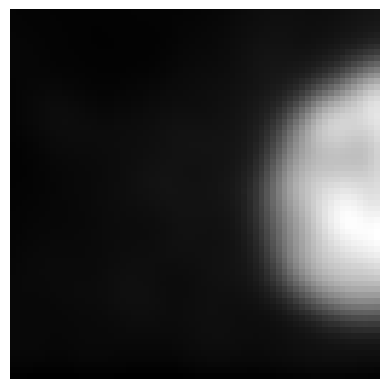

--- TARGET PATCH METADATA ---
Metadata Attributes:
{'affine': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), 'depth': '1', 'dimensions_present': 'YXC', 'dtype': 'uint8', 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510003.png', 'format': 'PNG', 'image_size_c': '3', 'image_size_x': '512', 'image_size_y': '512', 'kind': 'image', 'layout': 'CZYX', 'mode': 'RGB', 'original_channel_dim': '0', 'patch_size': '(64, 64)', 'patch_transforms': 'None', 'size_after_tfms': 'torch.Size([3, 1, 512, 512])', 'size_loaded': 'torch.Size([3, 1, 512, 512])', 'size_output': '(3, 1, 512, 512)', 'source_shape': '(3, 1, 512, 512)', 'space': 'RAS', 'spatial_shape': '(1, 512, 512)', 'transforms': "{'GaussianSmoothd': {'time': 0.009576574000675464, 'params': {'keys': ('gt',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 1, 'approx': 'erf'}}}}", 'patch_location': '(0, 64)'}

Affine Matrix:
[[1. 0. 0. 0.]
 [0. 1. 0.

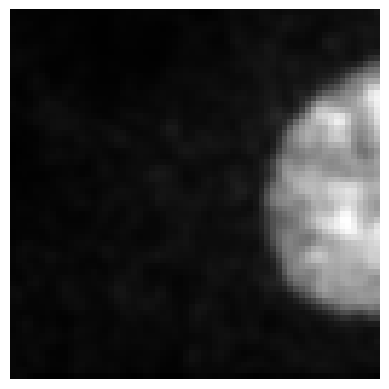

In [ ]:
# Extract target array pointers for input and ground truth (gt) from sample 1
input_file_path = f"{output_folder}/patches_dataset.h5/{manifest_df['image'][1]}"
gt_file_path = f"{output_folder}/patches_dataset.h5/{manifest_df['gt'][1]}"

# Load and visualize the preprocessed input patch array
im_in, meta_in, affine_in = hdf5_loader()(input_file_path)
print("--- INPUT PATCH METADATA ---")
print(f"Metadata Attributes:\n{meta_in}\n")
print(f"Affine Matrix:\n{affine_in}\n")
show_image(im_in)

# Load and visualize the preprocessed target (ground-truth) patch array
im_gt, meta_gt, affine_gt = hdf5_loader()(gt_file_path)
print("--- TARGET PATCH METADATA ---")
print(f"Metadata Attributes:\n{meta_gt}\n")
print(f"Affine Matrix:\n{affine_gt}\n")
show_image(im_gt)

##### Step 3: Randomized Sub-sampling with Downstream Patch Transforms

Alternatively, we can compile a dataset using a stochastic approach with a `RandomPatchSplitter`. In this scenario, augmentations (`patch_transforms`) are applied directly to individual extracted sub-patch slices instead of the global image.


Processing split: train


100%|██████████| 5/5 [00:00<00:00, 71.35it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 72.75it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset_random.h5
Patch information saved to CSV: ./_test_tfms/patches_dataset_random.csv
--- RANDOMIZED PATCH METADATA ---
{'affine': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), 'depth': '1', 'dimensions_present': 'YXC', 'dtype': 'uint8', 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510002.png', 'format': 'PNG', 'image_size_c': '3', 'image_size_x': '512', 'image_size_y': '512', 'kind': 'image', 'layout': 'CZYX', 'mode': 'RGB', 'original_channel_dim': '0', 'patch_size': '(64, 64)', 'patch_transforms': "{'GaussianSmoothd': {'__class__': 'GaussianSmoothd', 'keys': ('gt',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 1, 'approx': 'erf'}}}", 'size_after_tfms': 'torch.Size([3, 1, 512, 512])', 'size_loaded': 'torch.Size([3, 1, 512, 512])', 'size_output': '(3, 1, 512, 512)', 'source_shape': '(3, 1, 512, 512)', 'space':

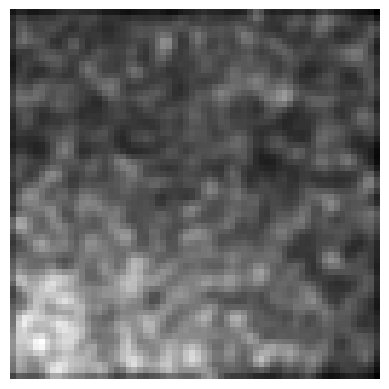

In [ ]:
# Execute end-to-end stochastic patch sub-sampling
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset_random',
    colmap=colmap, 
    patch_transforms=transforms_list, 
    image_splitter=RandomPatchSplitter(patch_size, num_patches=3), 
)

# Load and verify a sample from the randomized dataset matrix
random_df = pd.read_csv(f'{output_folder}/patches_dataset_random.csv')
random_h5_path = f"{output_folder}/patches_dataset_random.h5/{random_df['gt'][1]}"

rand_gt, rand_meta, _ = hdf5_loader()(random_h5_path)
print("--- RANDOMIZED PATCH METADATA ---")
print(rand_meta)
show_image(rand_gt)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()